# Receptor KD × selected CytoSignal LR score gene-level OLS

## Experiment summary

This notebook tests whether **spatial ligand–receptor context modifies the transcriptional effect of receptor knockdown**.

The analysis uses the integrated H5MU containing:

- `rna`: gene expression for the main 51-EB receptor perturbation dataset.
- `lr_cytosignal`: per-cell CytoSignal diffusion LR scores.
- `target_call`: perturbation label used to define KD and control cells.

Control definition follows `receptor_interaction_analysis.ipynb`:

```text
KD cells      = cells with target_call == current receptor / target
Control cells = cells with target_call == Non-Targeting
Excluded      = other KD targets, Unassigned, No_CRISPR_data, missing/nan labels
```

## Models fit in this notebook

For every selected `target × radius × LR score`, the notebook fits two gene-level models.

### 1. Nonspatial KD-only baseline model

This model ignores LR score and estimates the pooled KD effect:

$$
Y_g \sim KD_R
$$

It produces:

```text
beta_kd_nonspatial
p_kd_nonspatial
fdr_kd_nonspatial
```

This model tests whether the receptor KD affects gene `g` when spatial LR context is omitted.

### 2. Spatial LR interaction model

For each selected LR score at a given CytoSignal radius, the notebook fits:

$$
Y_g \sim KD_R + LR_j(r) + KD_R \times LR_j(r)
$$

It produces:

```text
beta_kd              # KD effect at mean-standardized LR score
beta_lr              # LR score association in control/background cells
beta_interaction     # how KD effect changes as LR score changes
fdr_interaction      # main test for spatial effect modification
```

The LR score is z-scored within the cells used by the model. Therefore:

$$
\text{KD effect at low LR} = \beta_{KD} - \beta_{interaction}
$$

$$
\text{KD effect at high LR} = \beta_{KD} + \beta_{interaction}
$$

A significant `beta_interaction` means that the receptor KD effect depends on the CytoSignal LR microenvironment.

## Why only selected LR scores?

The previous notebook, `Receptor_CytoSignal_LR_ElasticNet_Screen.ipynb`, first ranked LR scores using a fixed-alpha multi-output elastic-net screen on RNA PCs:

$$
RNA\ PCs \sim KD_R + LR_1 + \cdots + LR_p + KD_R \times LR_1 + \cdots + KD_R \times LR_p
$$

That screen selected top LR scores by `interaction_l2`, the L2 norm of the `KD × LR` coefficient across RNA PCs. This notebook then performs formal gene-level OLS only on those selected LR scores.

## Candidate ranking

After fitting all selected LR models, the notebook ranks `target × LR score × gene × radius` events using:

- `fdr_interaction`
- `abs(beta_interaction)`
- low-vs-high LR conditional KD effect difference
- gained/lost KD significance relative to the nonspatial baseline
- conditional low/high LR sign switches
- whether the LR receptor complex contains the KD target, `lr_receptor_contains_kd_target`

Important interpretation note: the LR scores were selected using the same dataset, so OLS p-values are best treated as follow-up/post-screening evidence. A later robustness notebook should use leave-one-EB, leave-one-lane, sample splitting, or spatial permutation controls for confirmatory evidence.


In [5]:
from __future__ import annotations

import json
import re
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import scipy.sparse as sp
from scipy.stats import t as t_dist
from statsmodels.stats.multitest import multipletests

import mudata as mu

import matplotlib.pyplot as plt

warnings.filterwarnings('ignore', category=FutureWarning)
pd.set_option('display.max_columns', 120)
pd.set_option('display.width', 180)


## 1. Configuration

In [6]:
INPUT_H5MU = Path('/scratch/luvul_root/luvul0/luvul/all_lanes_merged_with_cytosignal_diffusion_lr.h5mu')
SCREEN_DIR = Path('/scratch/luvul_root/luvul0/luvul/receptor_cytosignal_lr_elasticnet_screen_results')
SCREEN_CANDIDATE_CSV = SCREEN_DIR / 'candidate_lr_scores_for_single_lr_ols.csv'

OUTPUT_DIR = Path('/scratch/luvul_root/luvul0/luvul/receptor_cytosignal_top_lr_gene_level_ols_results')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

RNA_MOD = 'rna'
LR_MOD = 'lr_cytosignal'
PERTURBATION_COLUMN = 'target_call'
NEGATIVE_CONTROL_LABELS = {'Non-Targeting', 'non targeting', 'non-targeting', 'nontargeting', 'non_targeting', 'NTC'}
MISSING_PERTURBATION_LABELS = {'nan', '', 'none', 'na', 'NA', 'NaN', '<NA>'}
EXCLUDE_TARGET_LABELS = {'Unassigned', 'No_CRISPR_data'}

RADIUS_LAYERS = {
    100: 'radius_100um',
    200: 'radius_200um',
    400: 'radius_400um',
}

# Limit candidates for a first test run. Set to None for all rows in SCREEN_CANDIDATE_CSV.
MAX_CANDIDATE_ROWS = None

# Gene filters and OLS settings.
MIN_DETECTION_FRACTION = 0.05
MIN_TOTAL_CELLS = 50
MIN_KD_CELLS = 30
MIN_CONTROL_CELLS = 100
MIN_LR_SD = 1e-8

# Caching behavior.
FORCE_REFIT = False
FORCE_RESUMMARIZE = False
FORCE_EFFECT_MOD_RESUMMARIZE = False

# Summary thresholds.
FDR_THRESHOLD = 0.05
TOP_N_PLOT_EVENTS = 30

# Spatial effect-modification candidate ranking thresholds.
EFFECT_MOD_FDR_INTERACTION = 0.05
EFFECT_MOD_FDR_KD = 0.05
EFFECT_MOD_MIN_ABS_BETA_INTERACTION = 0.10
EFFECT_MOD_MIN_ABS_CONDITIONAL_DELTA = 0.20
EFFECT_MOD_TOP_N_TRAJECTORY_EVENTS = 40

print('Input:', INPUT_H5MU)
print('Screen candidates:', SCREEN_CANDIDATE_CSV)
print('Output dir:', OUTPUT_DIR)


Input: /scratch/luvul_root/luvul0/luvul/all_lanes_merged_with_cytosignal_diffusion_lr.h5mu
Screen candidates: /scratch/luvul_root/luvul0/luvul/receptor_cytosignal_lr_elasticnet_screen_results/candidate_lr_scores_for_single_lr_ols.csv
Output dir: /scratch/luvul_root/luvul0/luvul/receptor_cytosignal_top_lr_gene_level_ols_results


## 2. Load H5MU and selected LR candidates

In [3]:
assert INPUT_H5MU.is_file(), INPUT_H5MU
assert SCREEN_CANDIDATE_CSV.is_file(), SCREEN_CANDIDATE_CSV

def lr_receptor_contains_target(receptor_name, target):
    receptor_text = '' if pd.isna(receptor_name) else str(receptor_name).strip()
    target_text = '' if pd.isna(target) else str(target).strip()
    if not receptor_text or not target_text:
        return False
    parts = [p.strip().upper() for p in re.split(r'[+;,|/\s]+', receptor_text) if p.strip()]
    return target_text.upper() in parts


mdata = mu.read_h5mu(INPUT_H5MU)
rna = mdata.mod[RNA_MOD]
lr = mdata.mod[LR_MOD]

common_cells = rna.obs_names.intersection(lr.obs_names)
rna = rna[common_cells, :]
lr = lr[common_cells, :]

candidates = pd.read_csv(SCREEN_CANDIDATE_CSV)
if MAX_CANDIDATE_ROWS is not None:
    candidates = candidates.head(MAX_CANDIDATE_ROWS).copy()

required_cols = {'target', 'radius_um', 'lr_var_name'}
missing = required_cols - set(candidates.columns)
assert not missing, missing
candidates['radius_um'] = candidates['radius_um'].astype(int)
candidates['target'] = candidates['target'].astype(str)
candidates['lr_var_name'] = candidates['lr_var_name'].astype(str)
candidates = candidates.drop_duplicates(['target', 'radius_um', 'lr_var_name']).reset_index(drop=True)
if 'lr_receptor_contains_kd_target' not in candidates.columns:
    if 'receptor_name' in candidates.columns:
        candidates['lr_receptor_contains_kd_target'] = candidates.apply(
            lambda r: lr_receptor_contains_target(r['receptor_name'], r['target']), axis=1
        )
    else:
        candidates['lr_receptor_contains_kd_target'] = False
candidates.to_csv(OUTPUT_DIR / 'input_candidate_lr_scores_with_direct_match_flag.csv', index=False)

print(mdata)
print('RNA aligned:', rna.shape)
print('LR aligned:', lr.shape)
print('Candidate target × radius × LR rows:', len(candidates))
display(candidates.head(30))


MuData object with n_obs × n_vars = 17043 × 173195
  obs:	'nCount_RNA', 'nFeature_RNA', 'percent.mt', 'log10_nCount_RNA', 'log10_nFeature_RNA', 'nCount_SCT', 'nFeature_SCT', 'SCT_snn_res.0.2', 'seurat_clusters', 'gex_barcode', 'lane', 'guide_data_present', 'guide_call', 'call_status', 'guides_passing_str', 'guide_umis_passing_str', 'n_guides_passing', 'posterior_top_guide', 'posterior_top_probability', 'top_guide', 'top_guide_umis', 'second_guide_umis', 'total_guide_umis', 'n_guides_nonzero', 'top_fraction', 'top_minus_second', 'atac_barcode', 'atac_barcode_linked', 'global_cell_id', 'raw_cell_barcode', 'orig.ident', 'nCount_peaks', 'nFeature_peaks', 'barcode_raw', 'SPATIAL_1', 'SPATIAL_2', 'target_call', 'signac_call_status', 'top_target', 'top_target_umis', 'second_target_umis', 'total_target_umis', 'signac_top_fraction', 'signac_top_minus_second', 'n_targets_nonzero', 'merged_dataset', 'nucleosome_signal', 'TSS_enrichment', 'ATAC_total_counts', 'ATAC_peaks_detected', 'pass_percent_m

,target,radius_um,lr_index,lr_var_name,n_cells,n_kd,n_control,n_lr_scores_in_model,alpha,l1_ratio,kd_coef_l2_across_pcs,lr_main_l2,lr_main_max_abs,lr_main_nonzero_pc_fraction,interaction_l2,interaction_max_abs,interaction_nonzero_pc_fraction,lr_mean,lr_sd,lr_nonzero_fraction,ligand_name,receptor_name,lr_name,lr_type,interaction_rank,main_rank,lr_receptor_contains_kd_target
0,ACVR2B,100,463,CPI-SS0FAE75A75,2217,1636,581,433,0.01,0.5,0.402541,0.497427,0.247930,1.0,0.497519,0.263035,1.0,1.191534e-05,0.000283,0.012179,RLN1,RXFP1,RLN1_RXFP1,diffusion,1,1,False
1,ACVR2B,100,225,CPI-SS0445D021B,2217,1636,581,433,0.01,0.5,0.402541,0.437035,0.235006,1.0,0.473360,0.248885,1.0,9.946526e-05,0.001254,0.054578,PYY,NPY5R,PYY_NPY5R,diffusion,2,2,False
2,ACVR2B,100,127,CPI-SC08968AFE6,2217,1636,581,433,0.01,0.5,0.402541,0.302269,0.111198,1.0,0.421249,0.190400,1.0,1.038730e-01,0.167942,0.911592,MSTN,TGFBR1+ACVR2B,MSTN_TGFBR1+ACVR2B,diffusion,3,20,True
3,ACVR2B,100,108,CPI-CS0E997FABD,2217,1636,581,433,0.01,0.5,0.402541,0.250682,0.097656,1.0,0.386162,0.156705,1.0,7.615093e-02,0.100954,0.989175,BMP4,BMPR1B+ACVR2B,BMP4_BMPR1B+ACVR2B,diffusion,4,61,True
4,ACVR2B,100,311,CPI-SS084816B12,2217,1636,581,433,0.01,0.5,0.402541,0.339683,0.179060,1.0,0.369520,0.188494,1.0,3.468964e-08,0.000001,0.005413,HCRT,HCRTR1,HCRT_HCRTR1,diffusion,5,12,False
5,ACVR2B,100,68,CPI-CS0A6AB5149,2217,1636,581,433,0.01,0.5,0.402541,0.410447,0.188114,1.0,0.369091,0.138328,1.0,2.796767e-06,0.000089,0.013983,IL36B,IL1RL2+IL1RAP,IL36B_IL1RL2+IL1RAP,diffusion,6,4,False
6,ACVR2B,100,213,CPI-SS03DA2A820,2217,1636,581,433,0.01,0.5,0.402541,0.296671,0.112668,1.0,0.362147,0.134799,1.0,6.082826e-03,0.027786,0.372124,FGF2,CD44,FGF2_CD44,diffusion,7,25,False
7,ACVR2B,100,434,CPI-SS0E4DE8215,2217,1636,581,433,0.01,0.5,0.402541,0.163573,0.053371,1.0,0.355955,0.130465,1.0,1.146459e-04,0.002425,0.043302,WNT2,FZD1,WNT2_FZD1,diffusion,8,287,False
8,ACVR2B,100,313,CPI-SS0859C173B,2217,1636,581,433,0.01,0.5,0.402541,0.409572,0.239830,1.0,0.353744,0.193150,1.0,2.659478e-05,0.000555,0.016689,TNFSF14,LTBR,TNFSF14_LTBR,diffusion,9,5,False
9,ACVR2B,100,250,CPI-SS0577408A3,2217,1636,581,433,0.01,0.5,0.402541,0.147913,0.058626,1.0,0.352584,0.141039,1.0,1.774027e-04,0.002896,0.074876,CGA,FSHR,CGA_FSHR,diffusion,10,316,False


## 3. Helper functions

In [4]:
def safe_name(x):
    return re.sub(r'[^A-Za-z0-9_.-]+', '_', str(x))



def get_lr_matrix_for_radius(lr, radius_um):
    layer = RADIUS_LAYERS[int(radius_um)]
    if layer in lr.layers:
        return lr.layers[layer]
    if int(radius_um) == 200:
        return lr.X
    raise KeyError(f'Missing LR layer for radius {radius_um}: {layer}')


def dense_vector(x):
    if sp.issparse(x):
        x = x.toarray()
    return np.asarray(x).ravel()


def get_gene_names(rna):
    return np.asarray(rna.var_names.astype(str))


def get_control_mask(obs):
    raw = obs[PERTURBATION_COLUMN].astype(str).str.strip().str.lower()
    return raw.isin({x.lower() for x in NEGATIVE_CONTROL_LABELS}).to_numpy()


def get_target_mask(obs, target):
    raw = obs[PERTURBATION_COLUMN].astype(str).str.strip()
    return (raw == str(target)).to_numpy()


def vectorized_ols_one_lr(rna, cell_idx, kd_binary, lr_score, min_detection_fraction=0.05):
    n = len(cell_idx)
    if n < MIN_TOTAL_CELLS:
        return pd.DataFrame(), {'status': 'skipped_low_total_cells', 'n_cells': n}
    n_kd = int(kd_binary.sum())
    n_control = int(n - n_kd)
    if n_kd < MIN_KD_CELLS or n_control < MIN_CONTROL_CELLS:
        return pd.DataFrame(), {'status': 'skipped_low_group_cells', 'n_cells': n, 'n_kd': n_kd, 'n_control': n_control}

    lr_score = np.asarray(lr_score, dtype=float)
    lr_sd = float(np.nanstd(lr_score))
    if not np.isfinite(lr_sd) or lr_sd < MIN_LR_SD:
        return pd.DataFrame(), {'status': 'skipped_constant_lr_score', 'n_cells': n, 'n_kd': n_kd, 'n_control': n_control, 'lr_sd': lr_sd}
    lr_z = (lr_score - np.nanmean(lr_score)) / lr_sd
    kd = np.asarray(kd_binary, dtype=float)
    interaction = kd * lr_z
    X = np.column_stack([np.ones(n), kd, lr_z, interaction])
    p = X.shape[1]
    if n <= p + 1:
        return pd.DataFrame(), {'status': 'skipped_too_few_df', 'n_cells': n, 'n_kd': n_kd, 'n_control': n_control, 'lr_sd': lr_sd}

    XtX = X.T @ X
    try:
        XtX_inv = np.linalg.inv(XtX)
    except np.linalg.LinAlgError:
        XtX_inv = np.linalg.pinv(XtX)
    pinv = XtX_inv @ X.T

    Y = rna.X[cell_idx, :]
    if sp.issparse(Y):
        detection = np.asarray((Y > 0).mean(axis=0)).ravel()
        keep_genes = detection >= min_detection_fraction
        Y = Y[:, keep_genes].toarray()
    else:
        detection = np.asarray((Y > 0).mean(axis=0)).ravel()
        keep_genes = detection >= min_detection_fraction
        Y = np.asarray(Y[:, keep_genes])
    Y = Y.astype(float, copy=False)
    gene_names = get_gene_names(rna)[keep_genes]
    detection = detection[keep_genes]
    if Y.shape[1] == 0:
        return pd.DataFrame(), {'status': 'skipped_no_detected_genes', 'n_cells': n, 'n_kd': n_kd, 'n_control': n_control, 'lr_sd': lr_sd}

    betas = pinv @ Y
    residuals = Y - X @ betas
    dof = n - p
    sigma2 = (residuals ** 2).sum(axis=0) / dof
    se = np.sqrt(np.outer(np.diag(XtX_inv), sigma2))
    with np.errstate(divide='ignore', invalid='ignore'):
        t_stats = betas / se
    p_values = 2 * t_dist.sf(np.abs(t_stats), df=dof)

    # Also fit the nonspatial KD-only model on the same cells for gained/lost/sign-flip summaries.
    X0 = np.column_stack([np.ones(n), kd])
    XtX0 = X0.T @ X0
    try:
        XtX0_inv = np.linalg.inv(XtX0)
    except np.linalg.LinAlgError:
        XtX0_inv = np.linalg.pinv(XtX0)
    betas0 = XtX0_inv @ X0.T @ Y
    residuals0 = Y - X0 @ betas0
    dof0 = n - X0.shape[1]
    sigma20 = (residuals0 ** 2).sum(axis=0) / dof0
    se0 = np.sqrt(np.outer(np.diag(XtX0_inv), sigma20))
    with np.errstate(divide='ignore', invalid='ignore'):
        t_stats0 = betas0 / se0
    p_values0 = 2 * t_dist.sf(np.abs(t_stats0), df=dof0)

    out = pd.DataFrame({
        'gene': gene_names,
        'detection_fraction': detection,
        'beta_kd_nonspatial': betas0[1],
        'se_kd_nonspatial': se0[1],
        'p_kd_nonspatial': p_values0[1],
        'beta_kd': betas[1],
        'se_kd': se[1],
        'p_kd': p_values[1],
        'beta_lr': betas[2],
        'se_lr': se[2],
        'p_lr': p_values[2],
        'beta_interaction': betas[3],
        'se_interaction': se[3],
        'p_interaction': p_values[3],
    })
    for col in ['p_kd_nonspatial', 'p_kd', 'p_lr', 'p_interaction']:
        vals = out[col].replace([np.inf, -np.inf], np.nan).fillna(1.0).to_numpy()
        out[col.replace('p_', 'fdr_')] = multipletests(vals, method='fdr_bh')[1]
    qc = {
        'status': 'completed',
        'n_cells': n,
        'n_kd': n_kd,
        'n_control': n_control,
        'n_genes_tested': int(Y.shape[1]),
        'lr_mean': float(np.nanmean(lr_score)),
        'lr_sd': lr_sd,
        'lr_nonzero_fraction': float(np.mean(lr_score != 0)),
    }
    return out.sort_values('p_interaction').reset_index(drop=True), qc


## 4. Control/KD QC and candidate count

In [5]:
assert PERTURBATION_COLUMN in rna.obs.columns, PERTURBATION_COLUMN
control_mask = get_control_mask(rna.obs)
control_counts = (
    rna.obs.loc[control_mask, PERTURBATION_COLUMN]
    .astype(str).value_counts()
    .rename_axis('control_annotation_value')
    .reset_index(name='n_cells')
)
control_counts.to_csv(OUTPUT_DIR / 'negative_control_annotation_value_counts.csv', index=False)
print('Non-Targeting control cells:', int(control_mask.sum()))
display(control_counts)

target_qc_rows = []
for target in sorted(candidates['target'].unique()):
    kd_mask = get_target_mask(rna.obs, target)
    target_qc_rows.append({
        'target': target,
        'n_kd_cells': int(kd_mask.sum()),
        'n_control_cells': int(control_mask.sum()),
        'n_candidate_lr_radius_rows': int((candidates['target'] == target).sum()),
    })
target_qc = pd.DataFrame(target_qc_rows).sort_values('n_kd_cells', ascending=False)
target_qc.to_csv(OUTPUT_DIR / 'target_candidate_qc.csv', index=False)
display(target_qc)


Non-Targeting control cells: 581


,control_annotation_value,n_cells
0,Non-Targeting,581


,target,n_kd_cells,n_control_cells,n_candidate_lr_radius_rows
0,ACVR2B,1636,581,75
21,SEMA6D,867,581,75
7,EPHA7,677,581,75
22,VEGFB,646,581,75
3,BMP5,566,581,75
18,PDGFRA,555,581,75
4,BMP7,544,581,75
14,NECTIN3,514,581,75
6,EFNA3,491,581,75
19,PLXNA2,486,581,75


## 5. Fit selected single-LR gene-level OLS models

This section is resumable. Each `target × radius × LR score` writes one compressed CSV.

In [6]:
lr_index = {name: i for i, name in enumerate(lr.var_names.astype(str))}
all_qc = []
top_rows = []

for i, row in candidates.iterrows():
    target = str(row['target'])
    radius_um = int(row['radius_um'])
    lr_name = str(row['lr_var_name'])
    if target in EXCLUDE_TARGET_LABELS or target.lower() in {x.lower() for x in EXCLUDE_TARGET_LABELS}:
        continue
    if lr_name not in lr_index:
        all_qc.append({'target': target, 'radius_um': radius_um, 'lr_var_name': lr_name, 'status': 'skipped_lr_not_found'})
        continue

    safe = f"{safe_name(target)}__r{radius_um}um__{safe_name(lr_name)}"
    out_path = OUTPUT_DIR / f'{safe}_gene_level_ols.csv.gz'
    qc_path = OUTPUT_DIR / f'{safe}_gene_level_ols_qc.json'

    if out_path.exists() and qc_path.exists() and not FORCE_REFIT:
        qc = json.loads(qc_path.read_text())
        all_qc.append(qc)
        continue

    print(f'Fitting {i+1}/{len(candidates)}: target={target}, radius={radius_um}, LR={lr_name}')
    kd_mask = get_target_mask(rna.obs, target)
    model_mask = kd_mask | control_mask
    cell_idx = np.where(model_mask)[0]
    kd_binary = kd_mask[model_mask].astype(float)

    lr_matrix = get_lr_matrix_for_radius(lr, radius_um)
    lr_score = dense_vector(lr_matrix[cell_idx, lr_index[lr_name]])

    result, qc = vectorized_ols_one_lr(
        rna,
        cell_idx=cell_idx,
        kd_binary=kd_binary,
        lr_score=lr_score,
        min_detection_fraction=MIN_DETECTION_FRACTION,
    )
    qc.update({
        'target': target,
        'radius_um': radius_um,
        'lr_var_name': lr_name,
    })
    for meta_col in ['ligand_name', 'receptor_name', 'lr_name', 'lr_type']:
        if meta_col in row.index:
            qc[meta_col] = str(row[meta_col])
    qc['lr_receptor_contains_kd_target'] = bool(row.get('lr_receptor_contains_kd_target', False))
    direct_match = bool(row.get('lr_receptor_contains_kd_target', False))
    if len(result) > 0:
        for meta_col in ['ligand_name', 'receptor_name', 'lr_name', 'lr_type']:
            if meta_col in row.index:
                result[meta_col] = str(row[meta_col])
        result['lr_receptor_contains_kd_target'] = direct_match
        result.insert(0, 'lr_var_name', lr_name)
        result.insert(0, 'radius_um', radius_um)
        result.insert(0, 'target', target)
        result.to_csv(out_path, index=False, compression='gzip')
        top = result.head(20).copy()
        top_rows.append(top)
    qc_path.write_text(json.dumps(qc, indent=2))
    all_qc.append(qc)

model_qc = pd.DataFrame(all_qc)
model_qc.to_csv(OUTPUT_DIR / 'single_lr_gene_level_model_qc.csv', index=False)
display(model_qc.head(50))
print('Completed models:', int((model_qc['status'] == 'completed').sum()) if 'status' in model_qc else 0)


,status,n_cells,n_kd,n_control,n_genes_tested,lr_mean,lr_sd,lr_nonzero_fraction,target,radius_um,lr_var_name,ligand_name,receptor_name,lr_name,lr_type,lr_receptor_contains_kd_target
0,completed,2217,1636,581,10592,1.191534e-05,0.000283,0.012179,ACVR2B,100,CPI-SS0FAE75A75,RLN1,RXFP1,RLN1_RXFP1,diffusion,False
1,completed,2217,1636,581,10592,9.946524e-05,0.001254,0.054578,ACVR2B,100,CPI-SS0445D021B,PYY,NPY5R,PYY_NPY5R,diffusion,False
2,completed,2217,1636,581,10592,1.038732e-01,0.167942,0.911592,ACVR2B,100,CPI-SC08968AFE6,MSTN,TGFBR1+ACVR2B,MSTN_TGFBR1+ACVR2B,diffusion,True
3,completed,2217,1636,581,10592,7.615101e-02,0.100954,0.989175,ACVR2B,100,CPI-CS0E997FABD,BMP4,BMPR1B+ACVR2B,BMP4_BMPR1B+ACVR2B,diffusion,True
4,completed,2217,1636,581,10592,3.468964e-08,0.000001,0.005413,ACVR2B,100,CPI-SS084816B12,HCRT,HCRTR1,HCRT_HCRTR1,diffusion,False
5,completed,2217,1636,581,10592,2.796767e-06,0.000089,0.013983,ACVR2B,100,CPI-CS0A6AB5149,IL36B,IL1RL2+IL1RAP,IL36B_IL1RL2+IL1RAP,diffusion,False
6,completed,2217,1636,581,10592,6.082826e-03,0.027786,0.372124,ACVR2B,100,CPI-SS03DA2A820,FGF2,CD44,FGF2_CD44,diffusion,False
7,completed,2217,1636,581,10592,1.146459e-04,0.002425,0.043302,ACVR2B,100,CPI-SS0E4DE8215,WNT2,FZD1,WNT2_FZD1,diffusion,False
8,completed,2217,1636,581,10592,2.659478e-05,0.000555,0.016689,ACVR2B,100,CPI-SS0859C173B,TNFSF14,LTBR,TNFSF14_LTBR,diffusion,False
9,completed,2217,1636,581,10592,1.774026e-04,0.002896,0.074876,ACVR2B,100,CPI-SS0577408A3,CGA,FSHR,CGA_FSHR,diffusion,False


Completed models: 1875


## 6. Summarize significant interactions and top events

In [7]:
SUMMARY_CSV = OUTPUT_DIR / 'single_lr_interaction_summary.csv'
TOP_EVENTS_CSV = OUTPUT_DIR / 'top_single_lr_interaction_gene_events.csv'

if SUMMARY_CSV.is_file() and TOP_EVENTS_CSV.is_file() and not FORCE_RESUMMARIZE:
    print('Loading cached interaction summary:', SUMMARY_CSV)
    interaction_summary = pd.read_csv(SUMMARY_CSV)
    print('Loading cached top interaction events:', TOP_EVENTS_CSV)
    top_interaction_events = pd.read_csv(TOP_EVENTS_CSV)
else:
    print('Recomputing interaction summary from gene-level OLS files...')
    result_files = sorted(OUTPUT_DIR.glob('*_gene_level_ols.csv.gz'))
    print('Result files to scan:', len(result_files))
    summary_rows = []
    top_events = []
    for path in result_files:
        df = pd.read_csv(path)
        if df.empty:
            continue
        first = df.iloc[0]
        sig_int = df[df['fdr_interaction'] < FDR_THRESHOLD].copy()
        sig_kd = df[df['fdr_kd'] < FDR_THRESHOLD].copy()
        summary_rows.append({
            'target': first['target'],
            'radius_um': first['radius_um'],
            'lr_var_name': first['lr_var_name'],
            'ligand_name': first.get('ligand_name', ''),
            'receptor_name': first.get('receptor_name', ''),
            'lr_name': first.get('lr_name', ''),
            'lr_receptor_contains_kd_target': bool(first.get('lr_receptor_contains_kd_target', False)),
            'n_genes_tested': len(df),
            'n_significant_interaction_genes': len(sig_int),
            'n_significant_kd_genes': len(sig_kd),
            'best_interaction_fdr': float(df['fdr_interaction'].min()),
            'best_abs_beta_interaction': float(df.loc[df['fdr_interaction'].idxmin(), 'beta_interaction']),
        })
        if len(sig_int) > 0:
            top_events.append(sig_int.sort_values('fdr_interaction').head(50))

    interaction_summary = pd.DataFrame(summary_rows)
    if not interaction_summary.empty:
        interaction_summary = interaction_summary.sort_values(
            ['n_significant_interaction_genes', 'best_interaction_fdr'],
            ascending=[False, True]
        )
    interaction_summary.to_csv(SUMMARY_CSV, index=False)

    if top_events:
        top_interaction_events = pd.concat(top_events, ignore_index=True)
        top_interaction_events = top_interaction_events.sort_values('fdr_interaction')
    else:
        top_interaction_events = pd.DataFrame()
    top_interaction_events.to_csv(TOP_EVENTS_CSV, index=False)

display(interaction_summary.head(50))
display(top_interaction_events.head(50))

Loading cached interaction summary: /scratch/luvul_root/luvul0/luvul/receptor_cytosignal_top_lr_gene_level_ols_results/single_lr_interaction_summary.csv
Loading cached top interaction events: /scratch/luvul_root/luvul0/luvul/receptor_cytosignal_top_lr_gene_level_ols_results/top_single_lr_interaction_gene_events.csv


,target,radius_um,lr_var_name,ligand_name,receptor_name,lr_name,lr_receptor_contains_kd_target,n_genes_tested,n_significant_interaction_genes,n_significant_kd_genes,best_interaction_fdr,best_abs_beta_interaction
0,DLL3,100,CPI-SS0FC42EC80,EREG,ERBB4,EREG_ERBB4,False,10950,382,0,3.618136e-09,0.210361
1,EFNA3,100,CPI-SS0AE4CF4E7,CCL5,ACKR2,CCL5_ACKR2,False,11089,372,0,6.284466e-09,0.132067
2,B2M,400,CPI-SS0F562FEA5,CXCL2,CXCR2,CXCL2_CXCR2,False,10948,358,0,1.537704e-13,0.523878
3,PDGFRA,100,CPI-SS04EE957D8,CCL26,CCR1,CCL26_CCR1,False,10924,350,6,8.958723e-23,0.537417
4,FZD3,100,CPI-SS04297753E,SPP1,CCR8,SPP1_CCR8,False,11020,341,1,5.163129e-18,-0.521613
5,VEGFB,200,CPI-CS0A6AB5149,IL36B,IL1RL2+IL1RAP,IL36B_IL1RL2+IL1RAP,False,10896,330,0,1.789521e-14,-0.192768
6,PLXNA2,200,CPI-CS0A6AB5149,IL36B,IL1RL2+IL1RAP,IL36B_IL1RL2+IL1RAP,False,10945,330,2,6.851567e-11,-0.260968
7,PDGFRA,100,CPI-CS008C9D6E5,IL1B,IL1R2+IL1RAP,IL1B_IL1R2+IL1RAP,False,10924,325,10,5.364362e-07,0.970331
8,WNT5A,200,CPI-CS0A6AB5149,IL36B,IL1RL2+IL1RAP,IL36B_IL1RL2+IL1RAP,False,10913,317,0,3.515743e-11,-0.153501
9,BMP7,100,CPI-CS0A6AB5149,IL36B,IL1RL2+IL1RAP,IL36B_IL1RL2+IL1RAP,False,10971,316,3,1.860432e-14,-0.283514


,target,radius_um,lr_var_name,gene,detection_fraction,beta_kd_nonspatial,se_kd_nonspatial,p_kd_nonspatial,beta_kd,se_kd,p_kd,beta_lr,se_lr,p_lr,beta_interaction,se_interaction,p_interaction,fdr_kd_nonspatial,fdr_kd,fdr_lr,fdr_interaction,ligand_name,receptor_name,lr_name,lr_type,lr_receptor_contains_kd_target
0,PDGFC,100,CPI-SS04C396C5D,SST,0.058140,0.056903,0.035277,0.107072,0.081338,0.032085,0.011403,0.027735,0.016135,8.595748e-02,0.835119,0.063186,1.043045e-36,0.791256,0.506909,9.803181e-01,1.133060e-32,VGF,NTRK1,VGF_NTRK1,diffusion,False
1,EFNA3,100,CPI-SS0DA291AD9,GRIK1,0.058769,0.044525,0.023468,0.058064,0.076515,0.021990,0.000523,-0.002797,0.011026,7.997698e-01,0.902651,0.070571,5.883479e-35,0.879522,0.506985,8.670103e-01,6.524190e-31,CCL5,GPR75,CCL5_GPR75,diffusion,False
2,NECTIN2,400,CPI-SS04C396C5D,THSD7B,0.072549,0.044214,0.052032,0.395666,0.043149,0.045705,0.345359,0.140620,0.025606,5.030933e-08,0.658746,0.054725,2.715326e-31,0.972526,0.971719,3.647091e-05,2.952645e-27,VGF,NTRK1,VGF_NTRK1,diffusion,False
3,NECTIN2,400,CPI-SS04C396C5D,ANKFN1,0.050980,0.005735,0.026821,0.830719,0.005231,0.024067,0.827983,0.054285,0.013483,6.093327e-05,0.333743,0.028817,3.188275e-29,0.995950,0.995561,1.299193e-02,1.733465e-25,VGF,NTRK1,VGF_NTRK1,diffusion,False
4,NECTIN2,400,CPI-SS04C396C5D,CDH7,0.070588,0.031339,0.027085,0.247521,0.030844,0.024467,0.207738,0.052626,0.013708,1.310707e-04,0.328536,0.029296,1.340676e-27,0.959703,0.953190,2.201331e-02,4.859504e-24,VGF,NTRK1,VGF_NTRK1,diffusion,False
5,NECTIN2,400,CPI-SS04C396C5D,SST,0.053922,0.027240,0.032009,0.394958,0.026512,0.027042,0.327121,0.147303,0.015150,1.994573e-21,0.361240,0.032378,2.388296e-27,0.972526,0.971719,2.168899e-17,6.492582e-24,VGF,NTRK1,VGF_NTRK1,diffusion,False
6,NECTIN2,200,CPI-SS04C396C5D,SST,0.053922,0.027240,0.032009,0.394958,0.031565,0.028215,0.263514,0.107485,0.015543,8.243002e-12,0.392801,0.035453,5.173760e-27,0.972526,0.957065,2.987813e-08,5.625947e-23,VGF,NTRK1,VGF_NTRK1,diffusion,False
7,PDGFRA,100,CPI-SS04EE957D8,ELAC1,0.053697,-0.014034,0.015649,0.370027,0.009256,0.015029,0.538084,-0.002790,0.007533,7.111701e-01,0.537417,0.048854,8.200955e-27,0.874172,0.930209,9.927229e-01,8.958723e-23,CCL26,CCR1,CCL26_CCR1,diffusion,False
8,RSPO3,200,CPI-SS04C396C5D,KCNB2,0.068768,-0.031753,0.031222,0.309390,-0.008015,0.028672,0.779887,0.072113,0.015061,1.927383e-06,0.507636,0.046047,8.252347e-27,0.990107,0.996766,5.560737e-04,9.069329e-23,VGF,NTRK1,VGF_NTRK1,diffusion,False
9,B2M,400,CPI-CS09F211C3E,NDST3,0.056650,0.039394,0.032318,0.223219,0.044235,0.029580,0.135192,0.025768,0.014286,7.165221e-02,0.440738,0.040010,2.175926e-26,0.906984,0.871663,8.809975e-01,2.382203e-22,RAET1E,KLRK1+HCST,RAET1E_KLRK1+HCST,diffusion,False


## 6b. Spatial effect-modification candidate ranking

This section mirrors the candidate-ranking logic from `Kinase_Ligand_Interaction_Distance_Analysis.ipynb`. It ranks `target × LR score × gene × radius` events where the KD effect is strongly modified by the LR score.

Main signal: `fdr_interaction < EFFECT_MOD_FDR_INTERACTION` and a meaningful `beta_interaction` / low-vs-high conditional KD difference.


In [8]:
EFFECT_MOD_AUDIT_CSV = OUTPUT_DIR / 'effect_modification_model_audit.csv'
EFFECT_MOD_CANDIDATES_CSV = OUTPUT_DIR / 'spatial_effect_modification_candidates.csv'
EFFECT_MOD_BEST_PAIRS_CSV = OUTPUT_DIR / 'spatial_effect_modification_best_target_lr_gene_pairs.csv'
EFFECT_MOD_TYPE_SUMMARY_CSV = OUTPUT_DIR / 'effect_modification_candidate_type_summary.csv'
EFFECT_MOD_BY_TARGET_CSV = OUTPUT_DIR / 'effect_modification_by_target.csv'
EFFECT_MOD_BY_TARGET_LR_CSV = OUTPUT_DIR / 'effect_modification_by_target_lr_radius.csv'
EFFECT_MOD_DIRECT_MATCH_CSV = OUTPUT_DIR / 'effect_modification_direct_receptor_match_summary.csv'

_cached_effect_mod_files = [
    EFFECT_MOD_AUDIT_CSV,
    EFFECT_MOD_CANDIDATES_CSV,
    EFFECT_MOD_BEST_PAIRS_CSV,
    EFFECT_MOD_TYPE_SUMMARY_CSV,
    EFFECT_MOD_BY_TARGET_CSV,
    EFFECT_MOD_BY_TARGET_LR_CSV,
    EFFECT_MOD_DIRECT_MATCH_CSV,
]

if all(path.is_file() for path in _cached_effect_mod_files) and not FORCE_EFFECT_MOD_RESUMMARIZE:
    print('Loading cached spatial effect-modification summaries from:', OUTPUT_DIR)
    effect_modification_audit = pd.read_csv(EFFECT_MOD_AUDIT_CSV)
    effect_modification_candidates = pd.read_csv(EFFECT_MOD_CANDIDATES_CSV)
    best_gene_lr_pairs = pd.read_csv(EFFECT_MOD_BEST_PAIRS_CSV)
    candidate_type_summary = pd.read_csv(EFFECT_MOD_TYPE_SUMMARY_CSV)
    by_target = pd.read_csv(EFFECT_MOD_BY_TARGET_CSV)
    by_target_lr = pd.read_csv(EFFECT_MOD_BY_TARGET_LR_CSV)
    direct_match_summary = pd.read_csv(EFFECT_MOD_DIRECT_MATCH_CSV)
else:
    print('Recomputing spatial effect-modification summaries from gene-level OLS files...')
    # Build a ranked table of spatial effect-modification candidates.
    result_files = sorted(OUTPUT_DIR.glob('*_gene_level_ols.csv.gz'))
    candidate_frames = []
    audit_rows = []
    for path in result_files:
        df = pd.read_csv(path)
        if df.empty:
            continue
        # Backward compatibility if a partial old run lacks nonspatial KD-only columns.
        if 'beta_kd_nonspatial' not in df.columns:
            df['beta_kd_nonspatial'] = np.nan
            df['fdr_kd_nonspatial'] = np.nan
        df['abs_beta_interaction'] = df['beta_interaction'].abs()
        df['interaction_significant'] = df['fdr_interaction'] < EFFECT_MOD_FDR_INTERACTION
        df['spatial_kd_significant'] = df['fdr_kd'] < EFFECT_MOD_FDR_KD
        df['nonspatial_kd_significant'] = df['fdr_kd_nonspatial'] < EFFECT_MOD_FDR_KD
        df['conditional_kd_effect_low_score'] = df['beta_kd'] - df['beta_interaction']
        df['conditional_kd_effect_mid_score'] = df['beta_kd']
        df['conditional_kd_effect_high_score'] = df['beta_kd'] + df['beta_interaction']
        df['conditional_delta_high_minus_low'] = df['conditional_kd_effect_high_score'] - df['conditional_kd_effect_low_score']
        df['abs_conditional_delta_high_low'] = df['conditional_delta_high_minus_low'].abs()
        df['conditional_switch_low_high'] = (
            df['conditional_kd_effect_low_score'] * df['conditional_kd_effect_high_score'] < 0
        )
        df['sign_flip_nonspatial_to_spatial'] = (
            df['beta_kd_nonspatial'].notna()
            & (df['beta_kd_nonspatial'] * df['beta_kd'] < 0)
        )
        df['strict_reversal_with_interaction'] = (
            df['interaction_significant']
            & df['sign_flip_nonspatial_to_spatial']
            & df['nonspatial_kd_significant']
            & df['spatial_kd_significant']
        )
        df['large_interaction_effect'] = (
            df['interaction_significant']
            & (df['abs_beta_interaction'] >= EFFECT_MOD_MIN_ABS_BETA_INTERACTION)
        )
        df['large_conditional_delta'] = (
            df['interaction_significant']
            & (df['abs_conditional_delta_high_low'] >= EFFECT_MOD_MIN_ABS_CONDITIONAL_DELTA)
        )
        df['gained_kd_with_interaction'] = (
            df['interaction_significant']
            & (~df['nonspatial_kd_significant'].fillna(False))
            & df['spatial_kd_significant']
        )
        df['lost_kd_with_interaction'] = (
            df['interaction_significant']
            & df['nonspatial_kd_significant'].fillna(False)
            & (~df['spatial_kd_significant'])
        )
        df['conditional_switch_with_interaction'] = (
            df['interaction_significant'] & df['conditional_switch_low_high']
        )
        candidate_flags = [
            'strict_reversal_with_interaction',
            'large_interaction_effect',
            'large_conditional_delta',
            'gained_kd_with_interaction',
            'lost_kd_with_interaction',
            'conditional_switch_with_interaction',
        ]
        df['candidate_type'] = df[candidate_flags].apply(
            lambda r: '|'.join([c for c, v in r.items() if bool(v)]), axis=1
        )
        df['is_effect_modification_candidate'] = df['candidate_type'].astype(bool)
        df['effect_modification_rank_score'] = (
            -np.log10(df['fdr_interaction'].clip(lower=1e-300))
            * (df['abs_beta_interaction'] + 0.5 * df['abs_conditional_delta_high_low'])
        )
        cand = df[df['is_effect_modification_candidate']].copy()
        if len(cand):
            candidate_frames.append(cand)
        first = df.iloc[0]
        audit_rows.append({
            'target': first['target'],
            'radius_um': first['radius_um'],
            'lr_var_name': first['lr_var_name'],
            'lr_name': first.get('lr_name', ''),
            'lr_receptor_contains_kd_target': bool(first.get('lr_receptor_contains_kd_target', False)),
            'n_genes_tested': len(df),
            'n_interaction_significant': int(df['interaction_significant'].sum()),
            'n_effect_modification_candidates': int(df['is_effect_modification_candidate'].sum()),
            'best_fdr_interaction': float(df['fdr_interaction'].min()),
            'max_abs_beta_interaction': float(df['abs_beta_interaction'].max()),
        })

    effect_modification_audit = pd.DataFrame(audit_rows)
    effect_modification_audit.to_csv(OUTPUT_DIR / 'effect_modification_model_audit.csv', index=False)

    if candidate_frames:
        effect_modification_candidates = pd.concat(candidate_frames, ignore_index=True)
        effect_modification_candidates = effect_modification_candidates.sort_values(
            ['effect_modification_rank_score', 'fdr_interaction'], ascending=[False, True]
        ).reset_index(drop=True)
    else:
        effect_modification_candidates = pd.DataFrame()
    effect_modification_candidates.to_csv(
        OUTPUT_DIR / 'spatial_effect_modification_candidates.csv', index=False
    )

    if not effect_modification_candidates.empty:
        best_cols = ['target', 'lr_var_name', 'gene']
        best_gene_lr_pairs = (
            effect_modification_candidates.sort_values(['effect_modification_rank_score', 'fdr_interaction'], ascending=[False, True])
            .drop_duplicates(best_cols)
            .reset_index(drop=True)
        )
    else:
        best_gene_lr_pairs = pd.DataFrame()
    best_gene_lr_pairs.to_csv(OUTPUT_DIR / 'spatial_effect_modification_best_target_lr_gene_pairs.csv', index=False)

    candidate_flags = [
        'strict_reversal_with_interaction',
        'large_interaction_effect',
        'large_conditional_delta',
        'gained_kd_with_interaction',
        'lost_kd_with_interaction',
        'conditional_switch_with_interaction',
    ]
    type_rows = []
    for flag in candidate_flags:
        if effect_modification_candidates.empty or flag not in effect_modification_candidates:
            sub = pd.DataFrame()
        else:
            sub = effect_modification_candidates[effect_modification_candidates[flag]]
        type_rows.append({
            'candidate_type': flag,
            'n_gene_radius_lr_events': len(sub),
            'n_unique_target_lr_gene_pairs': sub[['target', 'lr_var_name', 'gene']].drop_duplicates().shape[0] if len(sub) else 0,
            'n_unique_genes': sub['gene'].nunique() if len(sub) else 0,
            'n_unique_targets': sub['target'].nunique() if len(sub) else 0,
            'n_unique_lr_scores': sub['lr_var_name'].nunique() if len(sub) else 0,
            'median_abs_beta_interaction': sub['abs_beta_interaction'].median() if len(sub) else np.nan,
            'median_abs_conditional_delta': sub['abs_conditional_delta_high_low'].median() if len(sub) else np.nan,
        })
    candidate_type_summary = pd.DataFrame(type_rows)
    candidate_type_summary.to_csv(OUTPUT_DIR / 'effect_modification_candidate_type_summary.csv', index=False)

    if not effect_modification_candidates.empty:
        by_target = (
            effect_modification_candidates.groupby('target', as_index=False)
            .agg(
                n_candidate_events=('gene', 'size'),
                n_candidate_genes=('gene', 'nunique'),
                n_candidate_lr_scores=('lr_var_name', 'nunique'),
                best_rank_score=('effect_modification_rank_score', 'max'),
                best_interaction_fdr=('fdr_interaction', 'min'),
                median_abs_beta_interaction=('abs_beta_interaction', 'median'),
            )
            .sort_values(['n_candidate_events', 'best_rank_score'], ascending=[False, False])
        )
        by_target_lr = (
            effect_modification_candidates.groupby(['target', 'radius_um', 'lr_var_name'], as_index=False)
            .agg(
                lr_name=('lr_name', 'first') if 'lr_name' in effect_modification_candidates.columns else ('gene', 'size'),
                ligand_name=('ligand_name', 'first') if 'ligand_name' in effect_modification_candidates.columns else ('gene', 'size'),
                receptor_name=('receptor_name', 'first') if 'receptor_name' in effect_modification_candidates.columns else ('gene', 'size'),
                lr_receptor_contains_kd_target=('lr_receptor_contains_kd_target', 'first') if 'lr_receptor_contains_kd_target' in effect_modification_candidates.columns else ('gene', 'size'),
                n_candidate_events=('gene', 'size'),
                n_candidate_genes=('gene', 'nunique'),
                best_rank_score=('effect_modification_rank_score', 'max'),
                best_interaction_fdr=('fdr_interaction', 'min'),
                median_abs_beta_interaction=('abs_beta_interaction', 'median'),
            )
            .sort_values(['n_candidate_events', 'best_rank_score'], ascending=[False, False])
        )
    else:
        by_target = pd.DataFrame()
        by_target_lr = pd.DataFrame()
    by_target.to_csv(OUTPUT_DIR / 'effect_modification_by_target.csv', index=False)
    by_target_lr.to_csv(OUTPUT_DIR / 'effect_modification_by_target_lr_radius.csv', index=False)

    if not effect_modification_candidates.empty and 'lr_receptor_contains_kd_target' in effect_modification_candidates.columns:
        direct_match_summary = (
            effect_modification_candidates.groupby('lr_receptor_contains_kd_target', as_index=False)
            .agg(
                n_candidate_events=('gene', 'size'),
                n_unique_target_lr_gene_pairs=('gene', lambda x: len(x)),
                n_unique_targets=('target', 'nunique'),
                n_unique_lr_scores=('lr_var_name', 'nunique'),
                median_abs_beta_interaction=('abs_beta_interaction', 'median'),
            )
        )
    else:
        direct_match_summary = pd.DataFrame()
    direct_match_summary.to_csv(OUTPUT_DIR / 'effect_modification_direct_receptor_match_summary.csv', index=False)

    print('Effect-modification candidates:', len(effect_modification_candidates))
    display(candidate_type_summary)
    display(by_target.head(30))
    display(by_target_lr.head(30))
    display(direct_match_summary)
    display(effect_modification_candidates.head(50))


# Common cached/recomputed display

print('Effect-modification candidates:', len(effect_modification_candidates))
display(candidate_type_summary)
display(by_target.head(30))
display(by_target_lr.head(30))
display(direct_match_summary)
display(effect_modification_candidates.head(50))


Loading cached spatial effect-modification summaries from: /scratch/luvul_root/luvul0/luvul/receptor_cytosignal_top_lr_gene_level_ols_results


Effect-modification candidates: 62406


,candidate_type,n_gene_radius_lr_events,n_unique_target_lr_gene_pairs,n_unique_genes,n_unique_targets,n_unique_lr_scores,median_abs_beta_interaction,median_abs_conditional_delta
0,strict_reversal_with_interaction,0,0,0,0,0,NaN,NaN
1,large_interaction_effect,54458,49642,9322,25,317,0.177426,0.354852
2,large_conditional_delta,54458,49642,9322,25,317,0.177426,0.354852
3,gained_kd_with_interaction,51,48,44,7,17,0.191007,0.382014
4,lost_kd_with_interaction,23,20,18,1,11,0.088860,0.177720
5,conditional_switch_with_interaction,62263,56427,9369,25,320,0.161765,0.323530


,target,n_candidate_events,n_candidate_genes,n_candidate_lr_scores,best_rank_score,best_interaction_fdr,median_abs_beta_interaction
0,NECTIN2,3630,2308,43,34.952808,2.952645e-27,0.144380
1,LGR4,3445,2450,52,14.306886,2.898007e-14,0.162921
2,B2M,3290,2498,53,21.999268,2.382203e-22,0.178619
3,FCGRT,3082,2102,51,17.504594,3.620851e-14,0.165208
4,JAG1,2864,1912,55,16.382653,1.777119e-12,0.162609
5,PDGFRA,2774,2047,37,23.697663,8.958723e-23,0.214991
6,DLL3,2722,2146,43,17.102961,7.817252e-17,0.157759
7,NECTIN3,2696,2106,50,19.225724,1.151298e-13,0.158419
8,ACVR2B,2677,1641,47,8.998355,3.848264e-17,0.109215
9,FZD3,2662,1920,49,18.034324,5.163129e-18,0.188596


,target,radius_um,lr_var_name,lr_name,ligand_name,receptor_name,lr_receptor_contains_kd_target,n_candidate_events,n_candidate_genes,best_rank_score,best_interaction_fdr,median_abs_beta_interaction
0,DLL3,100,CPI-SS0FC42EC80,EREG_ERBB4,EREG,ERBB4,False,382,382,3.551537,3.618136e-09,0.147867
1,EFNA3,100,CPI-SS0AE4CF4E7,CCL5_ACKR2,CCL5,ACKR2,False,372,372,2.268503,6.284466e-09,0.129413
2,B2M,400,CPI-SS0F562FEA5,CXCL2_CXCR2,CXCL2,CXCR2,False,358,358,13.425025,1.537704e-13,0.389838
3,PDGFRA,100,CPI-SS04EE957D8,CCL26_CCR1,CCL26,CCR1,False,350,350,23.697663,8.958723e-23,0.361101
4,FZD3,100,CPI-SS04297753E,SPP1_CCR8,SPP1,CCR8,False,341,341,18.034324,5.163129e-18,0.328524
5,PLXNA2,200,CPI-CS0A6AB5149,IL36B_IL1RL2+IL1RAP,IL36B,IL1RL2+IL1RAP,False,330,330,5.305059,6.851567e-11,0.110966
6,VEGFB,200,CPI-CS0A6AB5149,IL36B_IL1RL2+IL1RAP,IL36B,IL1RL2+IL1RAP,False,330,330,5.300067,1.789521e-14,0.112492
7,PDGFRA,100,CPI-CS008C9D6E5,IL1B_IL1R2+IL1RAP,IL1B,IL1R2+IL1RAP,False,325,325,12.168883,5.364362e-07,0.651285
8,WNT5A,200,CPI-CS0A6AB5149,IL36B_IL1RL2+IL1RAP,IL36B,IL1RL2+IL1RAP,False,317,317,3.568560,3.515743e-11,0.090480
9,BMP7,100,CPI-CS0A6AB5149,IL36B_IL1RL2+IL1RAP,IL36B,IL1RL2+IL1RAP,False,316,316,7.785520,1.860432e-14,0.164814


,lr_receptor_contains_kd_target,n_candidate_events,n_unique_target_lr_gene_pairs,n_unique_targets,n_unique_lr_scores,median_abs_beta_interaction
0,False,62382,62382,25,322,0.161712
1,True,24,24,3,4,0.085335


,target,radius_um,lr_var_name,gene,detection_fraction,beta_kd_nonspatial,se_kd_nonspatial,p_kd_nonspatial,beta_kd,se_kd,p_kd,beta_lr,se_lr,p_lr,beta_interaction,se_interaction,p_interaction,fdr_kd_nonspatial,fdr_kd,fdr_lr,fdr_interaction,ligand_name,receptor_name,lr_name,lr_type,lr_receptor_contains_kd_target,abs_beta_interaction,interaction_significant,spatial_kd_significant,nonspatial_kd_significant,conditional_kd_effect_low_score,conditional_kd_effect_mid_score,conditional_kd_effect_high_score,conditional_delta_high_minus_low,abs_conditional_delta_high_low,conditional_switch_low_high,sign_flip_nonspatial_to_spatial,strict_reversal_with_interaction,large_interaction_effect,large_conditional_delta,gained_kd_with_interaction,lost_kd_with_interaction,conditional_switch_with_interaction,candidate_type,is_effect_modification_candidate,effect_modification_rank_score
0,EFNA3,100,CPI-SS0DA291AD9,GRIK1,0.058769,0.044525,0.023468,0.058064,0.076515,0.021990,0.000523,-0.002797,0.011026,7.997698e-01,0.902651,0.070571,5.883479e-35,0.879522,0.506985,8.670103e-01,6.524190e-31,CCL5,GPR75,CCL5_GPR75,diffusion,False,0.902651,True,False,False,-0.826136,0.076515,0.979165,1.805301,1.805301,True,False,False,True,True,False,False,True,large_interaction_effect|large_conditional_del...,True,54.493871
1,PDGFC,100,CPI-SS04C396C5D,SST,0.058140,0.056903,0.035277,0.107072,0.081338,0.032085,0.011403,0.027735,0.016135,8.595748e-02,0.835119,0.063186,1.043045e-36,0.791256,0.506909,9.803181e-01,1.133060e-32,VGF,NTRK1,VGF_NTRK1,diffusion,False,0.835119,True,False,False,-0.753781,0.081338,0.916458,1.670239,1.670239,True,False,False,True,True,False,False,True,large_interaction_effect|large_conditional_del...,True,53.357024
2,NECTIN2,400,CPI-SS04C396C5D,THSD7B,0.072549,0.044214,0.052032,0.395666,0.043149,0.045705,0.345359,0.140620,0.025606,5.030933e-08,0.658746,0.054725,2.715326e-31,0.972526,0.971719,3.647091e-05,2.952645e-27,VGF,NTRK1,VGF_NTRK1,diffusion,False,0.658746,True,False,False,-0.615597,0.043149,0.701895,1.317493,1.317493,True,False,False,True,True,False,False,True,large_interaction_effect|large_conditional_del...,True,34.952808
3,EPHA7,200,CPI-SS0FEAC3352,MARVELD3,0.059618,0.010841,0.015779,0.492188,0.052835,0.015679,0.000775,-0.004235,0.007616,5.782359e-01,0.691397,0.066011,1.146292e-24,0.989602,0.366692,9.974389e-01,1.257941e-20,GALP,GALR3,GALP_GALR3,diffusion,False,0.691397,True,False,False,-0.638562,0.052835,0.744232,1.382793,1.382793,True,False,False,True,True,False,False,True,large_interaction_effect|large_conditional_del...,True,27.518058
4,NECTIN2,100,CPI-SS084816B12,CR1L,0.062745,-0.020492,0.020807,0.324924,-0.054759,0.020204,0.006836,0.716475,0.072436,4.356200e-22,-0.720012,0.073117,6.486263e-22,0.972526,0.779573,4.736932e-18,7.053163e-18,HCRT,HCRTR1,HCRT_HCRTR1,diffusion,False,0.720012,True,False,False,0.665253,-0.054759,-0.774771,-1.440024,1.440024,True,False,False,True,True,False,False,True,large_interaction_effect|large_conditional_del...,True,24.698742
5,EFNA3,100,CPI-SS0DA291AD9,CAMK4,0.066231,0.014079,0.018855,0.455408,0.035615,0.018070,0.048994,-0.003033,0.009061,7.378603e-01,0.609782,0.057993,1.128667e-24,0.971605,0.896947,8.648737e-01,6.257892e-21,CCL5,GPR75,CCL5_GPR75,diffusion,False,0.609782,True,False,False,-0.574167,0.035615,0.645397,1.219564,1.219564,True,False,False,True,True,False,False,True,large_interaction_effect|large_conditional_del...,True,24.639556
6,EFNA3,200,CPI-SS084816B12,ENSG00000249988,0.050373,0.019269,0.020794,0.354316,-0.001269,0.019924,0.949221,0.618249,0.059101,1.893781e-24,-0.621552,0.059945,4.563011e-24,0.960873,0.999914,2.100013e-20,5.059923e-20,HCRT,HCRTR1,HCRT_HCRTR1,diffusion,False,0.621552,True,False,False,0.620283,-0.001269,-0.622821,-1.243104,1.243104,True,True,False,True,True,False,False,True,large_interaction_effect|large_conditional_del...,True,23.986756
7,PDGFRA,100,CPI-SS04EE957D8,ELAC1,0.053697,-0.014034,0.015649,0.370027,0.009256,0.015029,0.538084,-0.002790,0.007533,7.111701e-01,0.537417,0.048

## 6c. Top candidate coefficient trajectories across LR-score radii

This section visualizes the strongest spatial effect-modification examples selected in section 6b.

For each top `target × LR score × gene` candidate, it loads only the corresponding gene-level OLS files across the available radii and plots how these quantities change with LR-score radius:

- `beta_kd`: KD effect at the mean standardized LR score for spatial models;
- `beta_kd_nonspatial`: radius-0 KD-only baseline, shown as the 0 µm point on the `beta_kd` trajectory;
- `beta_interaction`: how the KD effect changes with the LR score; this exists only for spatial LR-score models;
- `conditional_kd_effect_low_score = beta_kd - beta_interaction`;
- `conditional_kd_effect_high_score = beta_kd + beta_interaction`.

Important: radius 0 has no LR score, so `beta_interaction` and low/high LR-score conditional effects are not defined at 0 µm. The 0 µm point is only the nonspatial KD baseline.

This section does not refit models. It reads only the top candidate result files needed for the plots.

Trajectory rows: 110
Saved: /scratch/luvul_root/luvul0/luvul/receptor_cytosignal_top_lr_gene_level_ols_results/top_effect_modification_radius_trajectories.csv


,target,radius_um,lr_var_name,gene,detection_fraction,beta_kd_nonspatial,se_kd_nonspatial,p_kd_nonspatial,beta_kd,se_kd,p_kd,beta_lr,se_lr,p_lr,beta_interaction,se_interaction,p_interaction,fdr_kd_nonspatial,fdr_kd,fdr_lr,fdr_interaction,ligand_name,receptor_name,lr_name,lr_type,lr_receptor_contains_kd_target,result_file,pair_rank,trajectory_target,trajectory_lr_var_name,trajectory_gene,conditional_kd_effect_low_score,conditional_kd_effect_mid_score,conditional_kd_effect_high_score,trajectory_point_type
0,EFNA3,0,CPI-SS0DA291AD9,GRIK1,0.058769,0.044525,0.023468,0.058064,0.044525,0.023468,0.058064,NaN,NaN,NaN,NaN,NaN,NaN,0.879522,0.879522,8.670103e-01,NaN,CCL5,GPR75,CCL5_GPR75,diffusion,False,/scratch/luvul_root/luvul0/luvul/receptor_cyto...,0,EFNA3,CPI-SS0DA291AD9,GRIK1,NaN,0.044525,NaN,nonspatial_kd_baseline
1,EFNA3,100,CPI-SS0DA291AD9,GRIK1,0.058769,0.044525,0.023468,0.058064,0.076515,0.021990,0.000523,-0.002797,0.011026,7.997698e-01,0.902651,0.070571,5.883479e-35,0.879522,0.506985,8.670103e-01,6.524190e-31,CCL5,GPR75,CCL5_GPR75,diffusion,False,/scratch/luvul_root/luvul0/luvul/receptor_cyto...,0,EFNA3,CPI-SS0DA291AD9,GRIK1,-0.826136,0.076515,0.979165,spatial_lr_model
2,EFNA3,200,CPI-SS0DA291AD9,GRIK1,0.058769,0.044525,0.023468,0.058064,0.058236,0.022882,0.011066,-0.004158,0.011759,7.237203e-01,0.363131,0.046332,1.105325e-14,0.879522,0.793208,9.500748e-01,1.225695e-10,CCL5,GPR75,CCL5_GPR75,diffusion,False,/scratch/luvul_root/luvul0/luvul/receptor_cyto...,0,EFNA3,CPI-SS0DA291AD9,GRIK1,-0.304895,0.058236,0.421367,spatial_lr_model
3,EFNA3,400,CPI-SS0DA291AD9,GRIK1,0.058769,0.044525,0.023468,0.058064,0.045068,0.023419,0.054567,-0.002825,0.014583,8.464347e-01,0.052725,0.024311,3.032170e-02,0.879522,0.876186,9.973804e-01,9.161933e-01,CCL5,GPR75,CCL5_GPR75,diffusion,False,/scratch/luvul_root/luvul0/luvul/receptor_cyto...,0,EFNA3,CPI-SS0DA291AD9,GRIK1,-0.007657,0.045068,0.097793,spatial_lr_model
4,PDGFC,0,CPI-SS04C396C5D,SST,0.058140,0.056903,0.035277,0.107072,0.056903,0.035277,0.107072,NaN,NaN,NaN,NaN,NaN,NaN,0.791256,0.791256,9.803181e-01,NaN,VGF,NTRK1,VGF_NTRK1,diffusion,False,/scratch/luvul_root/luvul0/luvul/receptor_cyto...,1,PDGFC,CPI-SS04C396C5D,SST,NaN,0.056903,NaN,nonspatial_kd_baseline
5,PDGFC,100,CPI-SS04C396C5D,SST,0.058140,0.056903,0.035277,0.107072,0.081338,0.032085,0.011403,0.027735,0.016135,8.595748e-02,0.835119,0.063186,1.043045e-36,0.791256,0.506909,9.803181e-01,1.133060e-32,VGF,NTRK1,VGF_NTRK1,diffusion,False,/scratch/luvul_root/luvul0/luvul/receptor_cyto...,1,PDGFC,CPI-SS04C396C5D,SST,-0.753781,0.081338,0.916458,spatial_lr_model
6,NECTIN2,0,CPI-SS04C396C5D,THSD7B,0.072549,0.044214,0.052032,0.395666,0.044214,0.052032,0.395666,NaN,NaN,NaN,NaN,NaN,NaN,0.972526,0.972526,2.917875e-02,NaN,VGF,NTRK1,VGF_NTRK1,diffusion,False,/scratch/luvul_root/luvul0/luvul/receptor_cyto...,2,NECTIN2,CPI-SS04C396C5D,THSD7B,NaN,0.044214,NaN,nonspatial_kd_baseline
7,NECTIN2,200,CPI-SS04C396C5D,THSD7B,0.072549,0.044214,0.052032,0.395666,0.049931,0.048047,0.298951,0.093738,0.026468,4.158769e-04,0.604172,0.060372,1.502656e-22,0.972526,0.971021,2.917875e-02,5.446628e-19,VGF,NTRK1,VGF_NTRK1,diffusion,False,/scratch/luvul_root/luvul0/luvul/receptor_cyto...,2,NECTIN2,CPI-SS04C396C5D,THSD7B,-0.554242,0.049931,0.654103,spatial_lr_model
8,NECTIN2,400,CPI-SS04C396C5D,THSD7B,0.072549,0.044214,0.052032,0.395666,0.043149,0.045705,0.345359,0.140620,0.025606,5.030933e-08,0.658746,0.054725,2.715326e-31,0.972526,0.971719,3.647091e-05,2.952645e-27,VGF,NTRK1,VGF_NTRK1,diffusion,False,/scratch/luvul_root/luvul0/luvul/receptor_cyto...,2,NECTIN2,CPI-SS04C396C5D,THSD7B,-0.615597,0.043149,0.701895,spatial_lr_model
9,EPHA7,0,CPI-SS0FEAC3352,MARVELD3,0.059618,0.010841,0.015779,0.492188,0.010841,0.015779,0.492188,NaN,NaN,NaN,NaN,NaN,NaN,0.989602,0.989602,9.974389e-01,NaN,GALP,GALR3,GALP_GALR3,diffusion,False,/scratch/luvul_root/luvul0/luvul/receptor_cyto...,3,EPHA7,CPI-SS0FEAC3352,MARVELD3,NaN,0.010841,NaN,nonspatial_kd_baseline


Saved: /scratch/luvul_root/luvul0/luvul/receptor_cytosignal_top_lr_gene_level_ols_results/top_effect_modification_coefficient_trajectories.png


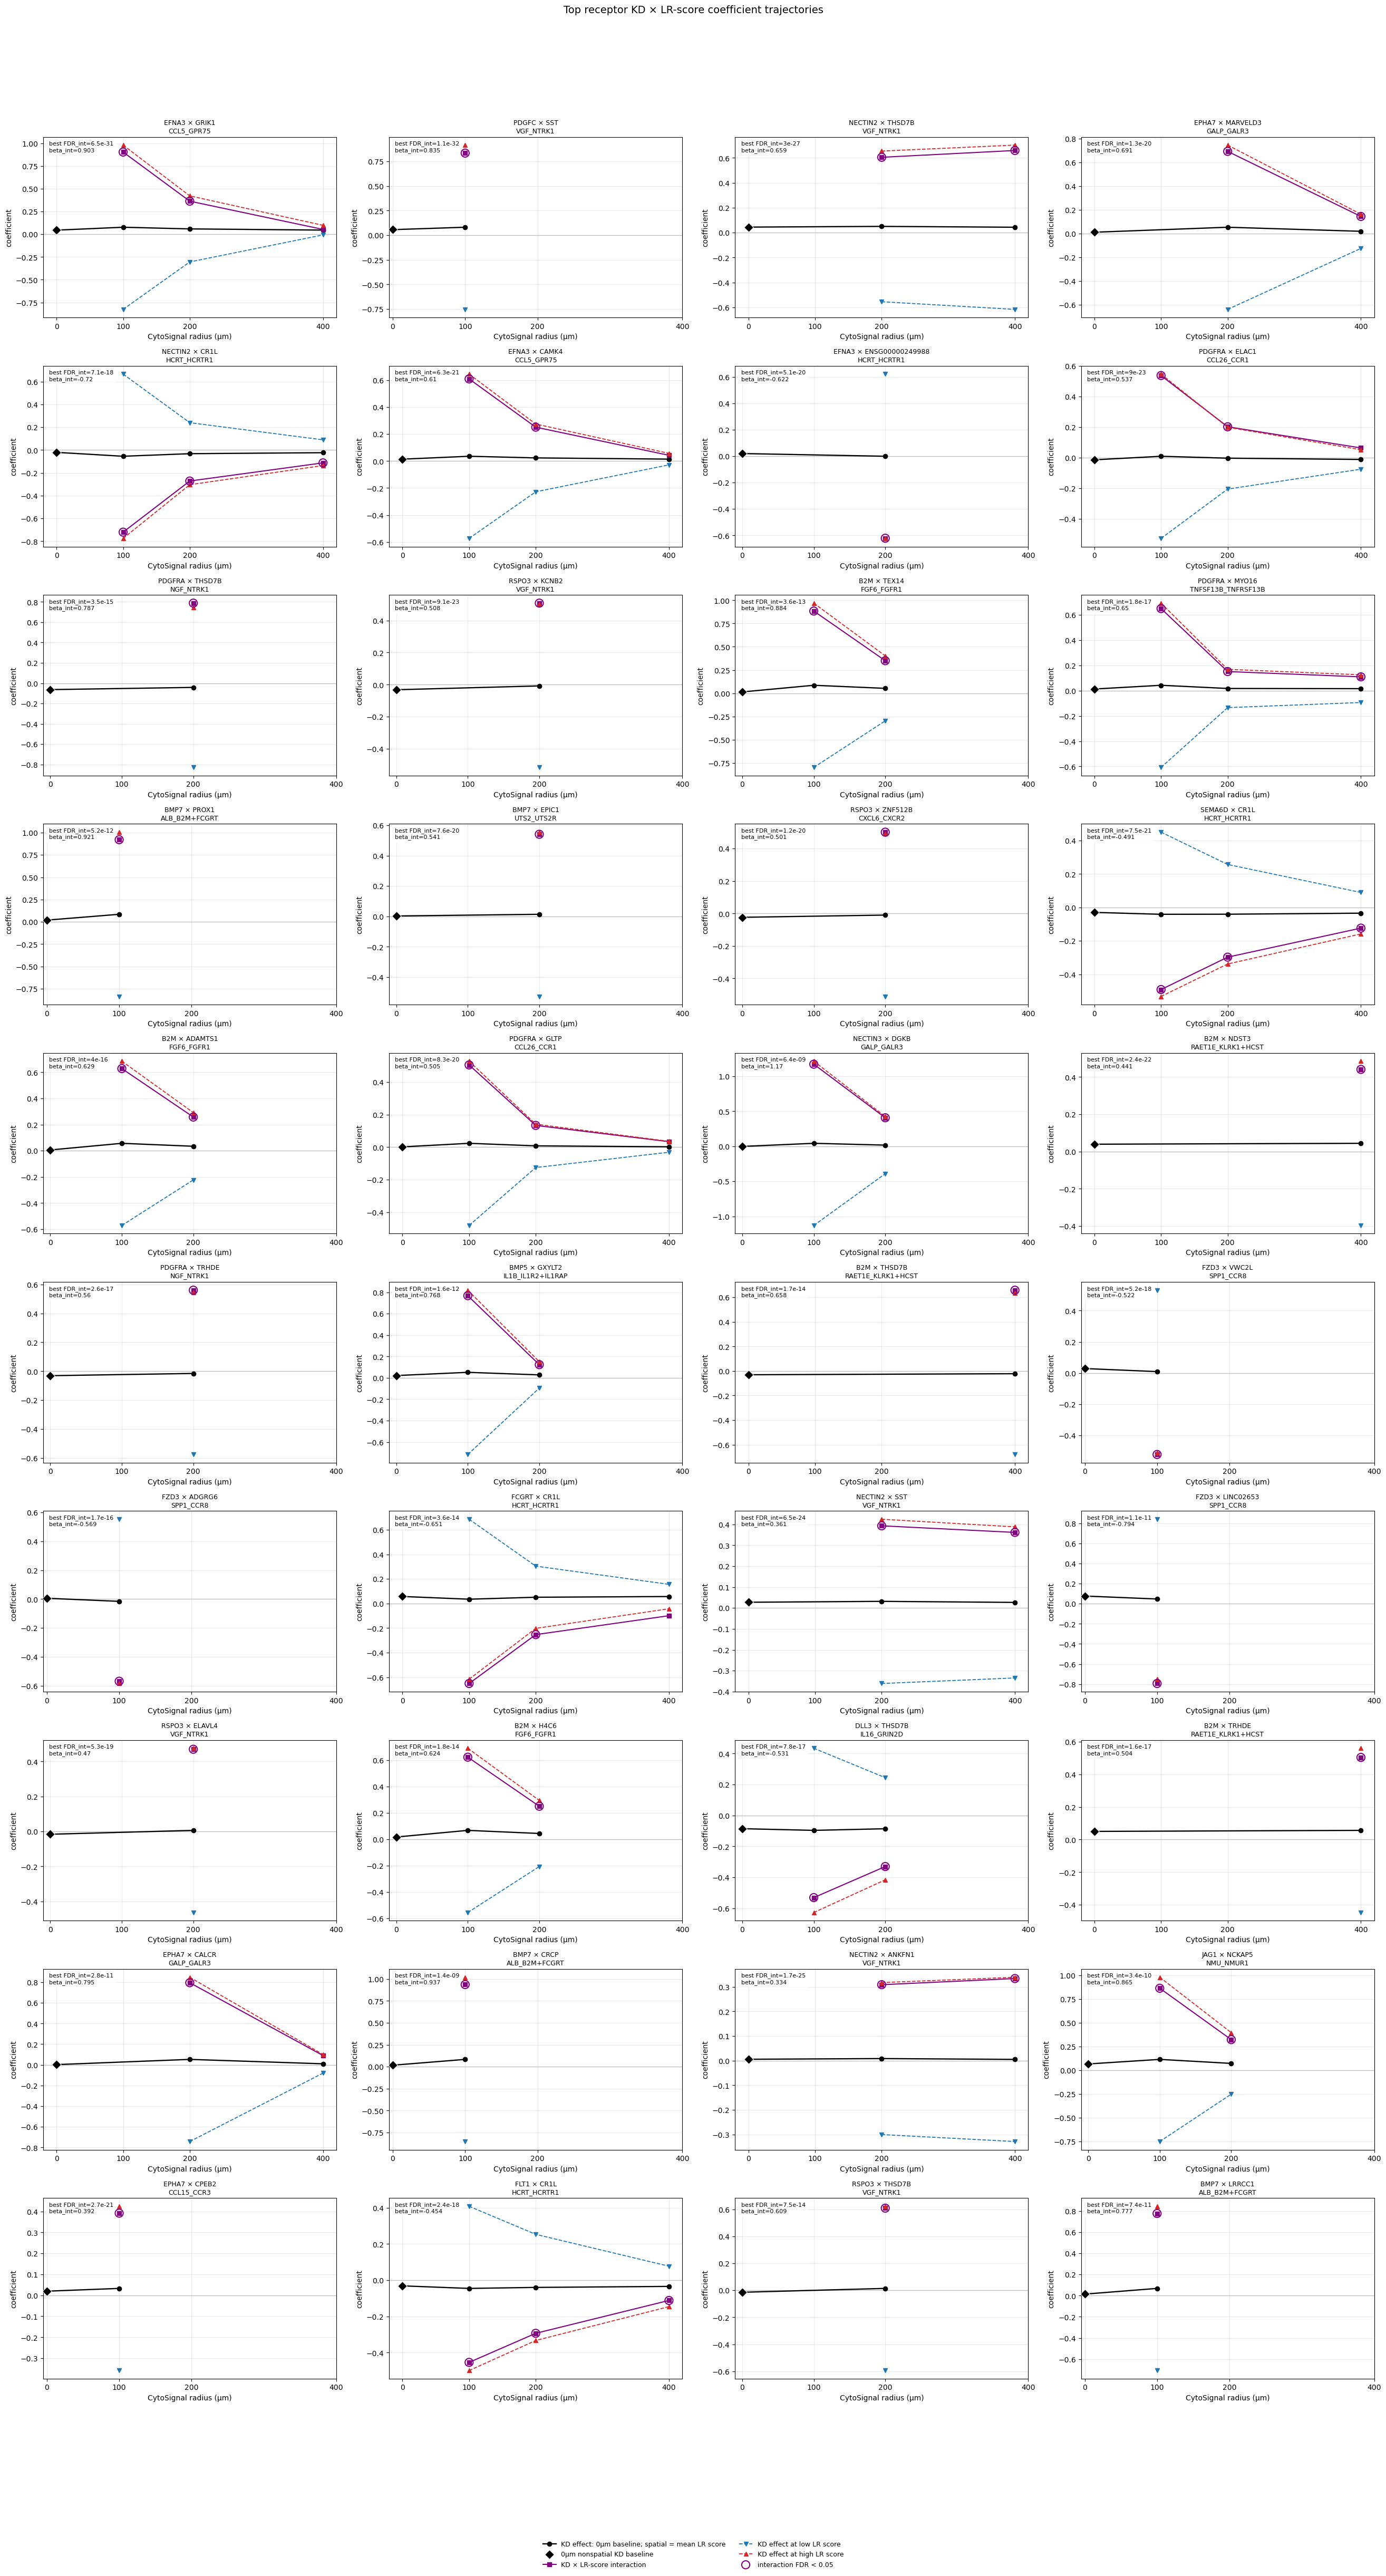

In [9]:
TOP_N_EFFECT_MOD_TRAJECTORY_PLOTS = 40
TRAJECTORY_OUTPUT_CSV = OUTPUT_DIR / 'top_effect_modification_radius_trajectories.csv'
TRAJECTORY_FIG_PATH = OUTPUT_DIR / 'top_effect_modification_coefficient_trajectories.png'


def _safe_read_gene_result_for_model(target, radius_um, lr_var_name, gene):
    path = OUTPUT_DIR / f'{safe_name(target)}__r{int(radius_um)}um__{safe_name(lr_var_name)}_gene_level_ols.csv.gz'
    if not path.is_file():
        return None
    try:
        df = pd.read_csv(path)
    except pd.errors.EmptyDataError:
        return None
    if df.empty or 'gene' not in df.columns:
        return None
    hit = df.loc[df['gene'].astype(str).eq(str(gene))]
    if hit.empty:
        return None
    row = hit.iloc[0].copy()
    row['result_file'] = str(path)
    return row


if 'best_gene_lr_pairs' in globals() and not best_gene_lr_pairs.empty:
    top_pairs = best_gene_lr_pairs.head(TOP_N_EFFECT_MOD_TRAJECTORY_PLOTS).copy()
elif 'effect_modification_candidates' in globals() and not effect_modification_candidates.empty:
    top_pairs = (
        effect_modification_candidates.sort_values(['effect_modification_rank_score', 'fdr_interaction'], ascending=[False, True])
        .drop_duplicates(['target', 'lr_var_name', 'gene'])
        .head(TOP_N_EFFECT_MOD_TRAJECTORY_PLOTS)
        .copy()
    )
else:
    top_pairs = pd.DataFrame()

trajectory_rows = []
if top_pairs.empty:
    print('No effect-modification candidate pairs available. Run section 6b first.')
else:
    radii_to_plot = sorted(int(r) for r in RADIUS_LAYERS)
    for pair_rank, pair in top_pairs.reset_index(drop=True).iterrows():
        target = str(pair['target'])
        lr_var_name = str(pair['lr_var_name'])
        gene = str(pair['gene'])
        spatial_rows_for_pair = []
        for radius_um in radii_to_plot:
            row = _safe_read_gene_result_for_model(target, radius_um, lr_var_name, gene)
            if row is None:
                continue
            row = row.to_dict()
            row['pair_rank'] = int(pair_rank)
            row['trajectory_target'] = target
            row['trajectory_lr_var_name'] = lr_var_name
            row['trajectory_gene'] = gene
            row['radius_um'] = int(radius_um)
            if 'conditional_kd_effect_low_score' not in row or pd.isna(row.get('conditional_kd_effect_low_score')):
                row['conditional_kd_effect_low_score'] = row['beta_kd'] - row['beta_interaction']
            if 'conditional_kd_effect_mid_score' not in row or pd.isna(row.get('conditional_kd_effect_mid_score')):
                row['conditional_kd_effect_mid_score'] = row['beta_kd']
            if 'conditional_kd_effect_high_score' not in row or pd.isna(row.get('conditional_kd_effect_high_score')):
                row['conditional_kd_effect_high_score'] = row['beta_kd'] + row['beta_interaction']
            row['trajectory_point_type'] = 'spatial_lr_model'
            spatial_rows_for_pair.append(row)
            trajectory_rows.append(row)

        # Add radius-0 nonspatial KD-only baseline once per target × LR × gene trajectory.
        # It is copied from the nonspatial columns stored in any available spatial model row.
        if spatial_rows_for_pair:
            base = dict(spatial_rows_for_pair[0])
            if 'beta_kd_nonspatial' in base and pd.notna(base.get('beta_kd_nonspatial')):
                baseline = base.copy()
                baseline['radius_um'] = 0
                baseline['beta_kd'] = baseline.get('beta_kd_nonspatial', np.nan)
                baseline['se_kd'] = baseline.get('se_kd_nonspatial', np.nan)
                baseline['p_kd'] = baseline.get('p_kd_nonspatial', np.nan)
                baseline['fdr_kd'] = baseline.get('fdr_kd_nonspatial', np.nan)
                baseline['beta_lr'] = np.nan
                baseline['se_lr'] = np.nan
                baseline['p_lr'] = np.nan
                baseline['beta_interaction'] = np.nan
                baseline['se_interaction'] = np.nan
                baseline['p_interaction'] = np.nan
                baseline['fdr_interaction'] = np.nan
                baseline['conditional_kd_effect_low_score'] = np.nan
                baseline['conditional_kd_effect_mid_score'] = baseline['beta_kd']
                baseline['conditional_kd_effect_high_score'] = np.nan
                baseline['trajectory_point_type'] = 'nonspatial_kd_baseline'
                trajectory_rows.append(baseline)

trajectory = pd.DataFrame(trajectory_rows)
if not trajectory.empty:
    trajectory = trajectory.sort_values(['pair_rank', 'radius_um']).reset_index(drop=True)
trajectory.to_csv(TRAJECTORY_OUTPUT_CSV, index=False)
print('Trajectory rows:', len(trajectory))
print('Saved:', TRAJECTORY_OUTPUT_CSV)
display(trajectory.head(30))

if trajectory.empty:
    print('No trajectory rows to plot.')
else:
    pair_keys = ['pair_rank', 'trajectory_target', 'trajectory_lr_var_name', 'trajectory_gene']
    n_pairs = trajectory[pair_keys].drop_duplicates().shape[0]
    n_cols = 4 if n_pairs > 12 else 3
    n_rows = int(np.ceil(n_pairs / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(6.6 * n_cols, 4.8 * n_rows), squeeze=False)

    grouped = trajectory.groupby(pair_keys, sort=True)
    for ax, ((pair_rank, target, lr_var_name, gene), sub) in zip(axes.ravel(), grouped):
        sub = sub.sort_values('radius_um')
        spatial = sub[sub['radius_um'].gt(0)].copy()
        baseline = sub[sub['radius_um'].eq(0)].copy()

        ax.axhline(0, color='0.78', linewidth=1, zorder=0)

        # beta_KD trajectory includes the radius-0 nonspatial baseline plus spatial beta_KD.
        kd_line = sub[['radius_um', 'beta_kd']].dropna().sort_values('radius_um')
        ax.plot(
            kd_line['radius_um'], kd_line['beta_kd'],
            marker='o', color='black', linewidth=1.7,
            label='KD effect: 0µm baseline; spatial = mean LR score',
        )
        if not baseline.empty:
            ax.scatter(
                baseline['radius_um'], baseline['beta_kd'],
                marker='D', s=80, color='black', edgecolors='white', linewidths=0.7,
                zorder=4, label='0µm nonspatial KD baseline',
            )

        if not spatial.empty:
            x = spatial['radius_um'].astype(float)
            ax.plot(
                x, spatial['beta_interaction'],
                marker='s', color='purple', linewidth=1.5,
                label='KD × LR-score interaction',
            )
            ax.plot(
                x, spatial['conditional_kd_effect_low_score'],
                marker='v', linestyle='--', color='tab:blue', linewidth=1.3,
                label='KD effect at low LR score',
            )
            ax.plot(
                x, spatial['conditional_kd_effect_high_score'],
                marker='^', linestyle='--', color='tab:red', linewidth=1.3,
                label='KD effect at high LR score',
            )

            sig = spatial['fdr_interaction'].astype(float) < FDR_THRESHOLD
            if sig.any():
                ax.scatter(
                    x[sig],
                    spatial.loc[sig, 'beta_interaction'],
                    s=120,
                    facecolors='none',
                    edgecolors='purple',
                    linewidths=1.5,
                    label='interaction FDR < 0.05',
                    zorder=5,
                )

        lr_label = spatial['lr_name'].dropna().astype(str).iloc[0] if 'lr_name' in spatial.columns and spatial['lr_name'].notna().any() else lr_var_name
        title = f'{target} × {gene}\n{lr_label}'
        ax.set_title(title, fontsize=9)
        ax.set_xlabel('CytoSignal radius (µm)')
        ax.set_ylabel('coefficient')
        ax.set_xticks([0, 100, 200, 400])
        ax.grid(alpha=0.25)

        if not spatial.empty:
            best = spatial.sort_values('fdr_interaction').iloc[0]
            ax.text(
                0.02, 0.98,
                f"best FDR_int={best['fdr_interaction']:.2g}\nbeta_int={best['beta_interaction']:.3g}",
                transform=ax.transAxes,
                ha='left', va='top', fontsize=8,
                bbox=dict(facecolor='white', alpha=0.75, edgecolor='none'),
            )

    for ax in axes.ravel()[len(grouped):]:
        ax.axis('off')

    # Build a clean global legend with unique labels, placed below the subplot grid.
    handles, labels = [], []
    for ax in axes.ravel()[:len(grouped)]:
        h, l = ax.get_legend_handles_labels()
        for handle, label in zip(h, l):
            if label not in labels:
                handles.append(handle)
                labels.append(label)
    fig.legend(
        handles, labels,
        loc='lower center',
        bbox_to_anchor=(0.5, -0.01),
        ncol=2,
        frameon=False,
        fontsize=9,
    )
    fig.suptitle('Top receptor KD × LR-score coefficient trajectories', y=1.005, fontsize=14)
    fig.tight_layout(rect=[0, 0.055, 1, 0.97])
    fig.savefig(TRAJECTORY_FIG_PATH, dpi=200, bbox_inches='tight')
    print('Saved:', TRAJECTORY_FIG_PATH)
    plt.show()

## 6d. Non-significant complete-radius control trajectories

This section draws comparison trajectories for non-significant examples. These are not selected from the significant effect-modification table.

Selection logic:

1. find `target × LR score` combinations with OLS results at all three spatial radii: 100, 200, and 400 µm;
2. within those complete-radius combinations, find genes present at all three radii;
3. require `fdr_interaction >= FDR_THRESHOLD` at every radius;
4. prefer examples with small maximum `abs(beta_interaction)` and high minimum interaction FDR;
5. require a nonspatial `beta_kd_nonspatial` baseline so the 0 µm point can be shown.

The goal is to compare the significant candidate trajectories from section 6c with visually matched non-significant examples that still have complete radius coverage.

Complete target × LR-score pairs with all radii: 54
Selected non-significant complete-radius examples: 40


,target,lr_var_name,gene,min_fdr_interaction,max_abs_beta_interaction,preferred_nonsig
0,ACVR2B,CPI-CS0A6AB5149,ADAMTS2,0.984433,0.000595,True
1,ACVR2B,CPI-SS0577408A3,MIAT,0.998046,0.000578,True
2,ACVR2B,CPI-SS084816B12,SNAP25,0.995997,0.000154,True
3,ALB,CPI-SS0098B5107,ENSG00000289396,0.998647,0.000260,True
4,B2M,CPI-SS04A7BCE8D,MAGEB17,0.998909,0.000271,True
5,B2M,CPI-SS0B0E74BC0,PARP16,0.997149,0.001425,True
6,BMP5,CPI-SS04297753E,KIAA1522,0.999608,0.000829,True
7,BMP5,CPI-SS0472C478C,IAH1,0.996934,0.001184,True
8,BMP7,CPI-SS091B461CB,FUT11,0.998079,0.001353,True
9,DLL3,CPI-SS08A819670,TVP23C,0.996445,0.000767,True


Non-significant trajectory rows: 160
Saved: /scratch/luvul_root/luvul0/luvul/receptor_cytosignal_top_lr_gene_level_ols_results/nonsignificant_complete_radius_trajectories.csv


,target,radius_um,lr_var_name,gene,detection_fraction,beta_kd_nonspatial,se_kd_nonspatial,p_kd_nonspatial,beta_kd,se_kd,p_kd,beta_lr,se_lr,p_lr,beta_interaction,se_interaction,p_interaction,fdr_kd_nonspatial,fdr_kd,fdr_lr,fdr_interaction,ligand_name,receptor_name,lr_name,lr_type,lr_receptor_contains_kd_target,result_file,pair_rank,trajectory_target,trajectory_lr_var_name,trajectory_gene,conditional_kd_effect_low_score,conditional_kd_effect_mid_score,conditional_kd_effect_high_score,trajectory_point_type
0,ACVR2B,0,CPI-CS0A6AB5149,ADAMTS2,0.065404,0.036893,0.015617,0.018244,0.036893,0.015617,0.018244,NaN,NaN,NaN,NaN,NaN,NaN,0.164876,0.164876,0.872695,NaN,IL36B,IL1RL2+IL1RAP,IL36B_IL1RL2+IL1RAP,diffusion,False,/scratch/luvul_root/luvul0/luvul/receptor_cyto...,0,ACVR2B,CPI-CS0A6AB5149,ADAMTS2,NaN,0.036893,NaN,nonspatial_kd_baseline
1,ACVR2B,100,CPI-CS0A6AB5149,ADAMTS2,0.065404,0.036893,0.015617,0.018244,0.036891,0.015623,0.018299,-0.002927,0.017551,0.867559,0.000470,0.019073,0.980344,0.164876,0.164957,0.872695,0.984433,IL36B,IL1RL2+IL1RAP,IL36B_IL1RL2+IL1RAP,diffusion,False,/scratch/luvul_root/luvul0/luvul/receptor_cyto...,0,ACVR2B,CPI-CS0A6AB5149,ADAMTS2,0.036421,0.036891,0.037361,spatial_lr_model
2,ACVR2B,200,CPI-CS0A6AB5149,ADAMTS2,0.065404,0.036893,0.015617,0.018244,0.036890,0.015624,0.018308,-0.000377,0.012403,0.975738,0.000595,0.014898,0.968144,0.164876,0.165207,0.988713,0.999938,IL36B,IL1RL2+IL1RAP,IL36B_IL1RL2+IL1RAP,diffusion,False,/scratch/luvul_root/luvul0/luvul/receptor_cyto...,0,ACVR2B,CPI-CS0A6AB5149,ADAMTS2,0.036295,0.036890,0.037485,spatial_lr_model
3,ACVR2B,400,CPI-CS0A6AB5149,ADAMTS2,0.065404,0.036893,0.015617,0.018244,0.036882,0.015619,0.018291,0.008346,0.013470,0.535600,-0.000115,0.015659,0.994126,0.164876,0.165304,0.957922,0.999330,IL36B,IL1RL2+IL1RAP,IL36B_IL1RL2+IL1RAP,diffusion,False,/scratch/luvul_root/luvul0/luvul/receptor_cyto...,0,ACVR2B,CPI-CS0A6AB5149,ADAMTS2,0.036998,0.036882,0.036767,spatial_lr_model
4,ACVR2B,0,CPI-SS0577408A3,MIAT,0.115471,0.009421,0.025780,0.714832,0.009421,0.025780,0.714832,NaN,NaN,NaN,NaN,NaN,NaN,0.910913,0.910913,0.921471,NaN,CGA,FSHR,CGA_FSHR,diffusion,False,/scratch/luvul_root/luvul0/luvul/receptor_cyto...,1,ACVR2B,CPI-SS0577408A3,MIAT,NaN,0.009421,NaN,nonspatial_kd_baseline
5,ACVR2B,100,CPI-SS0577408A3,MIAT,0.115471,0.009421,0.025780,0.714832,0.008622,0.025830,0.738567,-0.007210,0.011987,0.547586,0.000442,0.037405,0.990570,0.910913,0.919641,0.921471,0.998046,CGA,FSHR,CGA_FSHR,diffusion,False,/scratch/luvul_root/luvul0/luvul/receptor_cyto...,1,ACVR2B,CPI-SS0577408A3,MIAT,0.008180,0.008622,0.009064,spatial_lr_model
6,ACVR2B,200,CPI-SS0577408A3,MIAT,0.115471,0.009421,0.025780,0.714832,0.007591,0.025833,0.768892,-0.013021,0.013239,0.325431,-0.000249,0.025784,0.992307,0.910913,0.928950,0.973832,0.999144,CGA,FSHR,CGA_FSHR,diffusion,False,/scratch/luvul_root/luvul0/luvul/receptor_cyto...,1,ACVR2B,CPI-SS0577408A3,MIAT,0.007840,0.007591,0.007343,spatial_lr_model
7,ACVR2B,400,CPI-SS0577408A3,MIAT,0.115471,0.009421,0.025780,0.714832,0.005912,0.025850,0.819107,-0.022123,0.016693,0.185222,-0.000578,0.022781,0.979749,0.910913,0.948018,0.990857,0.999019,CGA,FSHR,CGA_FSHR,diffusion,False,/scratch/luvul_root/luvul0/luvul/receptor_cyto...,1,ACVR2B,CPI-SS0577408A3,MIAT,0.006491,0.005912,0.005334,spatial_lr_model
8,ACVR2B,0,CPI-SS084816B12,SNAP25,0.053676,0.037956,0.015094,0.011984,0.037956,0.015094,0.011984,NaN,NaN,NaN,NaN,NaN,NaN,0.126554,0.126554,0.893159,NaN,HCRT,HCRTR1,HCRT_HCRTR1,diffusion,False,/scratch/luvul_root/luvul0/luvul/receptor_cyto...,2,ACVR2B,CPI-SS084816B12,SNAP25,NaN,0.037956,NaN,nonspatial_kd_baseline
9,ACVR2B,100,CPI-SS084816B12,SNAP25,0.053676,0.037956,0.015094,0.011984,0.037935,0.015101,0.012071,-0.001931,0.013870,0.889280,-0.000152,0.015798,0.992330,0.126554,0.127505,0.893159,0.995997,HCRT,HCRTR1,HCRT_HCRTR1,diffusion,False,/scratch/luvul_root/luvul0/luvul/receptor_cyto...,2,ACVR2B,CPI-SS084816B12,SNAP25,0.038086,0.037935,0.037783,spatial_lr_model


Saved: /scratch/luvul_root/luvul0/luvul/receptor_cytosignal_top_lr_gene_level_ols_results/nonsignificant_complete_radius_coefficient_trajectories.png


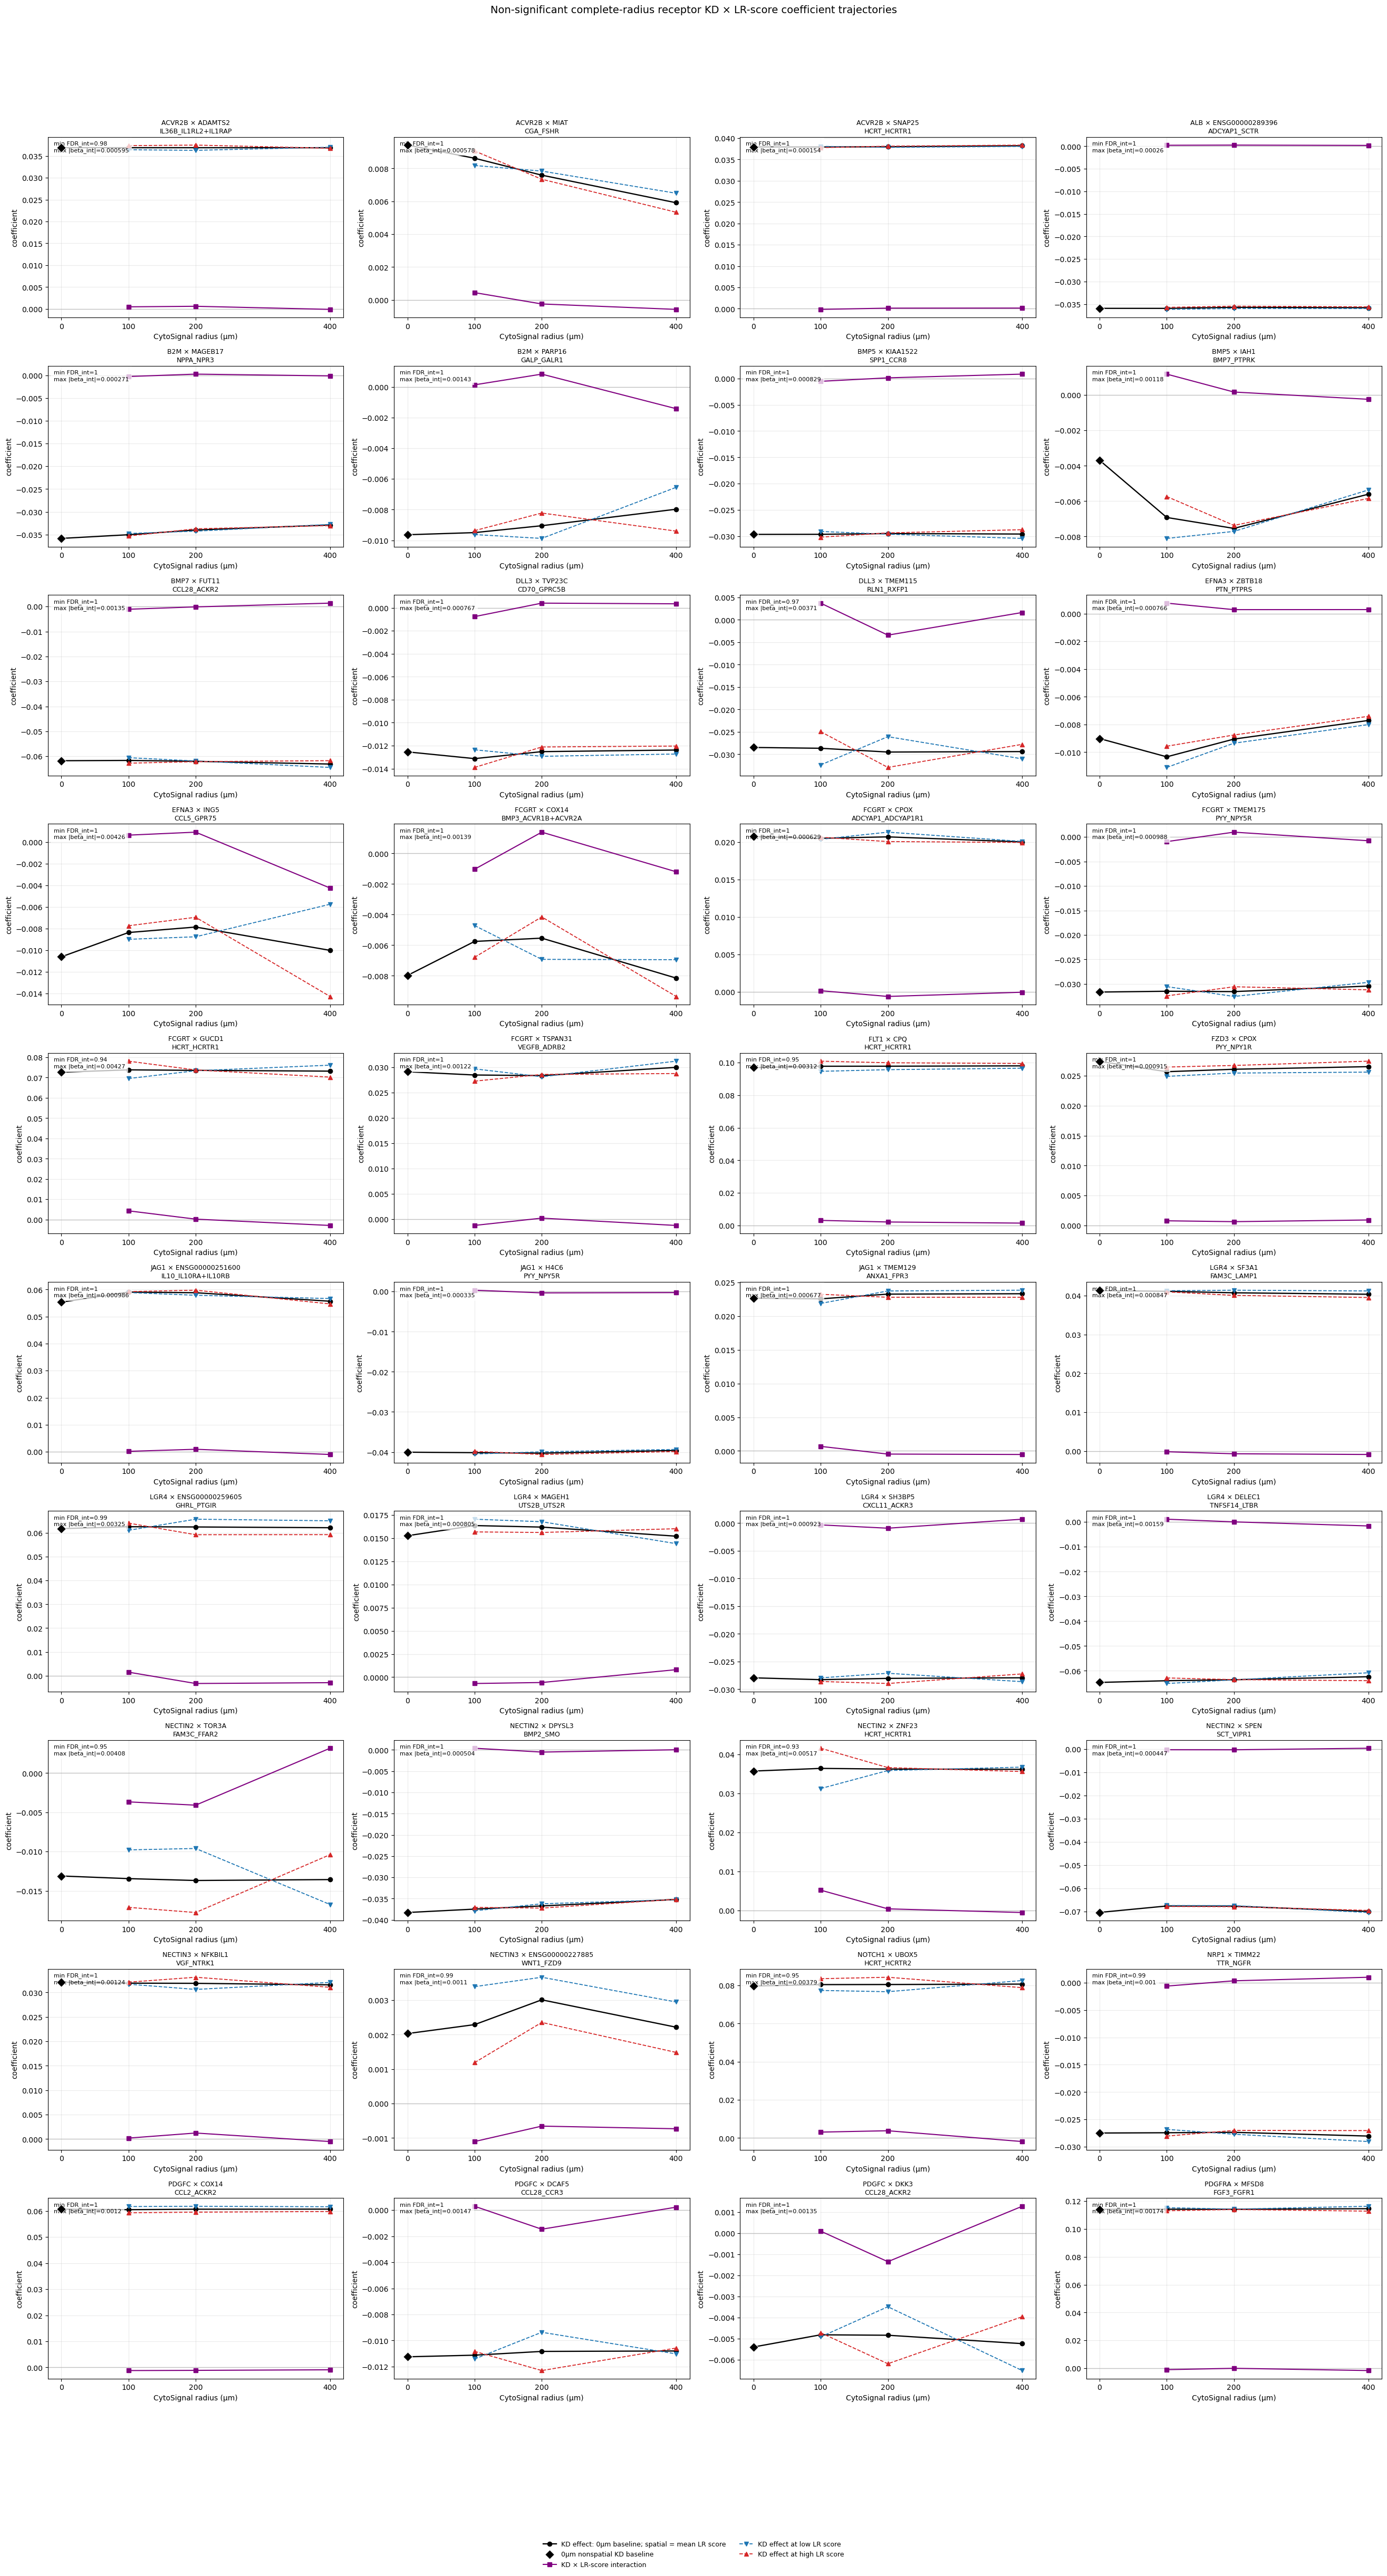

In [10]:
N_NONSIGNIFICANT_TRAJECTORY_PLOTS = TOP_N_EFFECT_MOD_TRAJECTORY_PLOTS
NONSIG_MIN_FDR_INTERACTION_ALL_RADII = FDR_THRESHOLD
NONSIG_PREFER_MIN_FDR_INTERACTION = 0.50
NONSIG_MAX_ABS_BETA_INTERACTION_PREFERRED = 0.05
NONSIG_TRAJECTORY_OUTPUT_CSV = OUTPUT_DIR / 'nonsignificant_complete_radius_trajectories.csv'
NONSIG_TRAJECTORY_FIG_PATH = OUTPUT_DIR / 'nonsignificant_complete_radius_coefficient_trajectories.png'

TRAJECTORY_USECOLS = [
    'target', 'radius_um', 'lr_var_name', 'gene', 'detection_fraction',
    'beta_kd_nonspatial', 'se_kd_nonspatial', 'p_kd_nonspatial',
    'beta_kd', 'se_kd', 'p_kd',
    'beta_lr', 'se_lr', 'p_lr',
    'beta_interaction', 'se_interaction', 'p_interaction',
    'fdr_kd_nonspatial', 'fdr_kd', 'fdr_lr', 'fdr_interaction',
    'ligand_name', 'receptor_name', 'lr_name', 'lr_type',
    'lr_receptor_contains_kd_target',
]


def _model_result_path(target, radius_um, lr_var_name):
    return OUTPUT_DIR / f'{safe_name(target)}__r{int(radius_um)}um__{safe_name(lr_var_name)}_gene_level_ols.csv.gz'


def _read_model_for_nonsig_search(target, radius_um, lr_var_name):
    path = _model_result_path(target, radius_um, lr_var_name)
    if not path.is_file():
        return None
    try:
        header = pd.read_csv(path, nrows=0)
        usecols = [c for c in TRAJECTORY_USECOLS if c in header.columns]
        df = pd.read_csv(path, usecols=usecols)
    except pd.errors.EmptyDataError:
        return None
    if df.empty or 'gene' not in df.columns:
        return None
    df['result_file'] = str(path)
    return df


# Candidate target × LR pairs with all three radius models available.
required_radii = sorted(int(r) for r in RADIUS_LAYERS)
if 'candidates' in globals() and not candidates.empty:
    candidate_triplets = candidates[['target', 'radius_um', 'lr_var_name']].drop_duplicates().copy()
else:
    candidate_triplets = pd.DataFrame(columns=['target', 'radius_um', 'lr_var_name'])

complete_pairs = []
for (target, lr_var_name), sub in candidate_triplets.groupby(['target', 'lr_var_name'], observed=True):
    radii_present = sorted(int(r) for r in sub['radius_um'].unique())
    if all(r in radii_present for r in required_radii):
        if all(_model_result_path(target, r, lr_var_name).is_file() for r in required_radii):
            complete_pairs.append({'target': str(target), 'lr_var_name': str(lr_var_name)})
complete_pairs = pd.DataFrame(complete_pairs)
print('Complete target × LR-score pairs with all radii:', len(complete_pairs))

selected_non_sig_pairs = []
search_audit = []
if complete_pairs.empty:
    print('No complete-radius target × LR-score pairs found.')
else:
    # Deterministic order: prefer diverse target/LR pairs rather than repeatedly choosing from the same target.
    complete_pairs = complete_pairs.sort_values(['target', 'lr_var_name']).reset_index(drop=True)
    for _, pair in complete_pairs.iterrows():
        if len(selected_non_sig_pairs) >= N_NONSIGNIFICANT_TRAJECTORY_PLOTS:
            break
        target = pair['target']
        lr_var_name = pair['lr_var_name']
        radius_frames = []
        ok = True
        for radius_um in required_radii:
            df = _read_model_for_nonsig_search(target, radius_um, lr_var_name)
            if df is None:
                ok = False
                break
            radius_frames.append(df)
        if not ok:
            continue

        merged = None
        for radius_um, df in zip(required_radii, radius_frames):
            keep_cols = [
                'gene', 'beta_kd_nonspatial', 'fdr_kd_nonspatial',
                'beta_kd', 'beta_lr', 'beta_interaction',
                'fdr_kd', 'fdr_lr', 'fdr_interaction',
                'ligand_name', 'receptor_name', 'lr_name', 'lr_type',
            ]
            keep_cols = [c for c in keep_cols if c in df.columns]
            tmp = df[keep_cols].copy()
            tmp = tmp.rename(columns={c: f'{c}_r{radius_um}' for c in tmp.columns if c != 'gene'})
            merged = tmp if merged is None else merged.merge(tmp, on='gene', how='inner')
        if merged is None or merged.empty:
            search_audit.append({'target': target, 'lr_var_name': lr_var_name, 'status': 'no_common_genes'})
            continue

        fdr_cols = [f'fdr_interaction_r{r}' for r in required_radii]
        beta_int_cols = [f'beta_interaction_r{r}' for r in required_radii]
        baseline_cols = [f'beta_kd_nonspatial_r{r}' for r in required_radii if f'beta_kd_nonspatial_r{r}' in merged.columns]
        mask = np.ones(len(merged), dtype=bool)
        for col in fdr_cols:
            mask &= merged[col].astype(float).ge(NONSIG_MIN_FDR_INTERACTION_ALL_RADII)
        if baseline_cols:
            mask &= merged[baseline_cols].notna().any(axis=1).to_numpy()
        nonsig = merged.loc[mask].copy()
        if nonsig.empty:
            search_audit.append({'target': target, 'lr_var_name': lr_var_name, 'status': 'no_nonsig_common_genes'})
            continue

        nonsig['min_fdr_interaction'] = nonsig[fdr_cols].astype(float).min(axis=1)
        nonsig['max_abs_beta_interaction'] = nonsig[beta_int_cols].astype(float).abs().max(axis=1)
        nonsig['preferred_nonsig'] = (
            nonsig['min_fdr_interaction'].ge(NONSIG_PREFER_MIN_FDR_INTERACTION)
            & nonsig['max_abs_beta_interaction'].le(NONSIG_MAX_ABS_BETA_INTERACTION_PREFERRED)
        )
        nonsig = nonsig.sort_values(
            ['preferred_nonsig', 'max_abs_beta_interaction', 'min_fdr_interaction'],
            ascending=[False, True, False],
        )
        chosen = nonsig.iloc[0]
        selected_non_sig_pairs.append({
            'target': target,
            'lr_var_name': lr_var_name,
            'gene': str(chosen['gene']),
            'min_fdr_interaction': float(chosen['min_fdr_interaction']),
            'max_abs_beta_interaction': float(chosen['max_abs_beta_interaction']),
            'preferred_nonsig': bool(chosen['preferred_nonsig']),
        })
        search_audit.append({'target': target, 'lr_var_name': lr_var_name, 'status': 'selected', 'gene': str(chosen['gene'])})

selected_non_sig_pairs = pd.DataFrame(selected_non_sig_pairs)
search_audit = pd.DataFrame(search_audit)
search_audit.to_csv(OUTPUT_DIR / 'nonsignificant_complete_radius_search_audit.csv', index=False)
print('Selected non-significant complete-radius examples:', len(selected_non_sig_pairs))
display(selected_non_sig_pairs.head(30))

# Build trajectory table in the same format as section 6c.
nonsig_rows = []
for pair_rank, pair in selected_non_sig_pairs.reset_index(drop=True).iterrows():
    target = str(pair['target'])
    lr_var_name = str(pair['lr_var_name'])
    gene = str(pair['gene'])
    spatial_rows_for_pair = []
    for radius_um in required_radii:
        row = _safe_read_gene_result_for_model(target, radius_um, lr_var_name, gene)
        if row is None:
            continue
        row = row.to_dict()
        row['pair_rank'] = int(pair_rank)
        row['trajectory_target'] = target
        row['trajectory_lr_var_name'] = lr_var_name
        row['trajectory_gene'] = gene
        row['radius_um'] = int(radius_um)
        row['conditional_kd_effect_low_score'] = row['beta_kd'] - row['beta_interaction']
        row['conditional_kd_effect_mid_score'] = row['beta_kd']
        row['conditional_kd_effect_high_score'] = row['beta_kd'] + row['beta_interaction']
        row['trajectory_point_type'] = 'spatial_lr_model'
        spatial_rows_for_pair.append(row)
        nonsig_rows.append(row)
    if spatial_rows_for_pair:
        base = dict(spatial_rows_for_pair[0])
        if 'beta_kd_nonspatial' in base and pd.notna(base.get('beta_kd_nonspatial')):
            baseline = base.copy()
            baseline['radius_um'] = 0
            baseline['beta_kd'] = baseline.get('beta_kd_nonspatial', np.nan)
            baseline['se_kd'] = baseline.get('se_kd_nonspatial', np.nan)
            baseline['p_kd'] = baseline.get('p_kd_nonspatial', np.nan)
            baseline['fdr_kd'] = baseline.get('fdr_kd_nonspatial', np.nan)
            baseline['beta_lr'] = np.nan
            baseline['se_lr'] = np.nan
            baseline['p_lr'] = np.nan
            baseline['beta_interaction'] = np.nan
            baseline['se_interaction'] = np.nan
            baseline['p_interaction'] = np.nan
            baseline['fdr_interaction'] = np.nan
            baseline['conditional_kd_effect_low_score'] = np.nan
            baseline['conditional_kd_effect_mid_score'] = baseline['beta_kd']
            baseline['conditional_kd_effect_high_score'] = np.nan
            baseline['trajectory_point_type'] = 'nonspatial_kd_baseline'
            nonsig_rows.append(baseline)

nonsig_trajectory = pd.DataFrame(nonsig_rows)
if not nonsig_trajectory.empty:
    nonsig_trajectory = nonsig_trajectory.sort_values(['pair_rank', 'radius_um']).reset_index(drop=True)
nonsig_trajectory.to_csv(NONSIG_TRAJECTORY_OUTPUT_CSV, index=False)
print('Non-significant trajectory rows:', len(nonsig_trajectory))
print('Saved:', NONSIG_TRAJECTORY_OUTPUT_CSV)
display(nonsig_trajectory.head(30))

if nonsig_trajectory.empty:
    print('No non-significant complete-radius trajectories to plot.')
else:
    pair_keys = ['pair_rank', 'trajectory_target', 'trajectory_lr_var_name', 'trajectory_gene']
    n_pairs = nonsig_trajectory[pair_keys].drop_duplicates().shape[0]
    n_cols = 4 if n_pairs > 12 else 3
    n_rows = int(np.ceil(n_pairs / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(6.6 * n_cols, 4.8 * n_rows), squeeze=False)

    grouped = nonsig_trajectory.groupby(pair_keys, sort=True)
    for ax, ((pair_rank, target, lr_var_name, gene), sub) in zip(axes.ravel(), grouped):
        sub = sub.sort_values('radius_um')
        spatial = sub[sub['radius_um'].gt(0)].copy()
        baseline = sub[sub['radius_um'].eq(0)].copy()

        ax.axhline(0, color='0.78', linewidth=1, zorder=0)
        kd_line = sub[['radius_um', 'beta_kd']].dropna().sort_values('radius_um')
        ax.plot(kd_line['radius_um'], kd_line['beta_kd'], marker='o', color='black', linewidth=1.7, label='KD effect: 0µm baseline; spatial = mean LR score')
        if not baseline.empty:
            ax.scatter(baseline['radius_um'], baseline['beta_kd'], marker='D', s=80, color='black', edgecolors='white', linewidths=0.7, zorder=4, label='0µm nonspatial KD baseline')
        if not spatial.empty:
            x = spatial['radius_um'].astype(float)
            ax.plot(x, spatial['beta_interaction'], marker='s', color='purple', linewidth=1.5, label='KD × LR-score interaction')
            ax.plot(x, spatial['conditional_kd_effect_low_score'], marker='v', linestyle='--', color='tab:blue', linewidth=1.3, label='KD effect at low LR score')
            ax.plot(x, spatial['conditional_kd_effect_high_score'], marker='^', linestyle='--', color='tab:red', linewidth=1.3, label='KD effect at high LR score')

        lr_label = spatial['lr_name'].dropna().astype(str).iloc[0] if 'lr_name' in spatial.columns and spatial['lr_name'].notna().any() else lr_var_name
        ax.set_title(f'{target} × {gene}\n{lr_label}', fontsize=9)
        ax.set_xlabel('CytoSignal radius (µm)')
        ax.set_ylabel('coefficient')
        ax.set_xticks([0, 100, 200, 400])
        ax.grid(alpha=0.25)
        if not spatial.empty:
            best = spatial.sort_values('fdr_interaction').iloc[0]
            ax.text(
                0.02, 0.98,
                f"min FDR_int={spatial['fdr_interaction'].min():.2g}\nmax |beta_int|={spatial['beta_interaction'].abs().max():.3g}",
                transform=ax.transAxes,
                ha='left', va='top', fontsize=8,
                bbox=dict(facecolor='white', alpha=0.75, edgecolor='none'),
            )

    for ax in axes.ravel()[len(grouped):]:
        ax.axis('off')

    handles, labels = [], []
    for ax in axes.ravel()[:len(grouped)]:
        h, l = ax.get_legend_handles_labels()
        for handle, label in zip(h, l):
            if label not in labels:
                handles.append(handle)
                labels.append(label)
    fig.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.5, -0.01), ncol=2, frameon=False, fontsize=9)
    fig.suptitle('Non-significant complete-radius receptor KD × LR-score coefficient trajectories', y=1.005, fontsize=14)
    fig.tight_layout(rect=[0, 0.055, 1, 0.97])
    fig.savefig(NONSIG_TRAJECTORY_FIG_PATH, dpi=200, bbox_inches='tight')
    print('Saved:', NONSIG_TRAJECTORY_FIG_PATH)
    plt.show()

## 7. QC plots

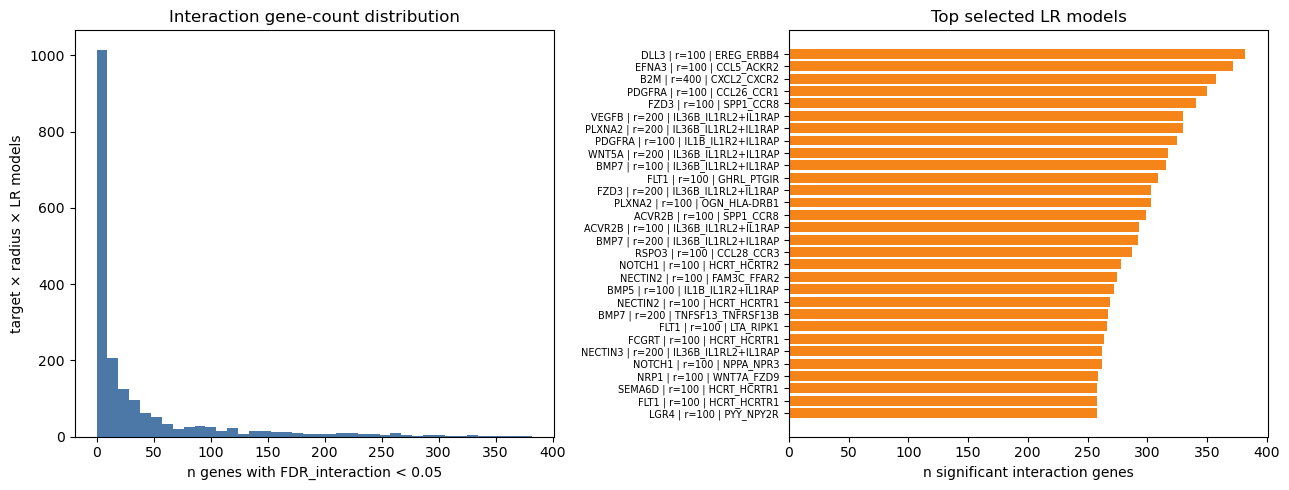

,file,path
0,ACVR2B__r100um__CPI-CS01319F57A_gene_level_ols...,/scratch/luvul_root/luvul0/luvul/receptor_cyto...
1,ACVR2B__r100um__CPI-CS01319F57A_gene_level_ols...,/scratch/luvul_root/luvul0/luvul/receptor_cyto...
2,ACVR2B__r100um__CPI-CS073D36B1D_gene_level_ols...,/scratch/luvul_root/luvul0/luvul/receptor_cyto...
3,ACVR2B__r100um__CPI-CS073D36B1D_gene_level_ols...,/scratch/luvul_root/luvul0/luvul/receptor_cyto...
4,ACVR2B__r100um__CPI-CS0A6AB5149_gene_level_ols...,/scratch/luvul_root/luvul0/luvul/receptor_cyto...
...,...,...
3765,spatial_effect_modification_candidates.csv,/scratch/luvul_root/luvul0/luvul/receptor_cyto...
3766,target_candidate_qc.csv,/scratch/luvul_root/luvul0/luvul/receptor_cyto...
3767,top_effect_modification_coefficient_trajectori...,/scratch/luvul_root/luvul0/luvul/receptor_cyto...
3768,top_effect_modification_radius_trajectories.csv,/scratch/luvul_root/luvul0/luvul/receptor_cyto...


All outputs under: /scratch/luvul_root/luvul0/luvul/receptor_cytosignal_top_lr_gene_level_ols_results


In [11]:
if 'interaction_summary' in globals() and not interaction_summary.empty:
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    axes[0].hist(interaction_summary['n_significant_interaction_genes'], bins=40, color='#4C78A8')
    axes[0].set_xlabel('n genes with FDR_interaction < 0.05')
    axes[0].set_ylabel('target × radius × LR models')
    axes[0].set_title('Interaction gene-count distribution')

    top = interaction_summary.head(TOP_N_PLOT_EVENTS).iloc[::-1].copy()
    labels = top['target'].astype(str) + ' | r=' + top['radius_um'].astype(str) + ' | ' + top['lr_name'].fillna(top['lr_var_name']).astype(str)
    axes[1].barh(np.arange(len(top)), top['n_significant_interaction_genes'], color='#F58518')
    axes[1].set_yticks(np.arange(len(top)))
    axes[1].set_yticklabels(labels, fontsize=7)
    axes[1].set_xlabel('n significant interaction genes')
    axes[1].set_title('Top selected LR models')
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / 'single_lr_gene_level_interaction_summary.png', dpi=200, bbox_inches='tight')
    plt.show()

manifest = pd.DataFrame({
    'file': [p.name for p in sorted(OUTPUT_DIR.glob('*')) if p.is_file()],
    'path': [str(p) for p in sorted(OUTPUT_DIR.glob('*')) if p.is_file()],
})
manifest.to_csv(OUTPUT_DIR / 'single_lr_gene_level_output_manifest.csv', index=False)
display(manifest)
print('All outputs under:', OUTPUT_DIR)


## Post-hoc project-wide FDR and project-wide candidate tables

This section does **not** refit any model and does not modify the cached
gene-level result files. Benjamini–Hochberg correction is recomputed across
the full project separately for each coefficient family.

The new significant-interaction and top-event tables are selected using
`fdr_interaction_projectwide < PROJECTWIDE_FDR_ALPHA`. Existing model-wise FDR
columns and existing candidate tables are retained for comparison.


In [12]:
import sys
_PROJECTWIDE_HELPER_DIR = Path('/home/luvul/non-autonomous_analysis')
if str(_PROJECTWIDE_HELPER_DIR) not in sys.path:
    sys.path.insert(0, str(_PROJECTWIDE_HELPER_DIR))
from projectwide_fdr import compute_projectwide_fdr

PROJECTWIDE_FDR_ALPHA = 0.05
PROJECTWIDE_TOP_N_PER_MODEL = 50
PROJECTWIDE_FDR_ROOT = OUTPUT_DIR / 'projectwide_fdr_posthoc'

projectwide_result_files = sorted(OUTPUT_DIR.glob('*_gene_level_ols.csv.gz'))
projectwide_input = pd.read_csv(
    OUTPUT_DIR / 'input_candidate_lr_scores_with_direct_match_flag.csv'
)
projectwide_model_qc_path = OUTPUT_DIR / 'single_lr_gene_level_model_qc.csv'
if not projectwide_model_qc_path.is_file():
    raise RuntimeError(
        'The model-fitting loop has not completed. Run this post-hoc section '
        'only after single_lr_gene_level_model_qc.csv has been written.'
    )
projectwide_model_qc = pd.read_csv(projectwide_model_qc_path)
if len(projectwide_model_qc) != len(projectwide_input):
    raise RuntimeError(
        f'Incomplete fitting audit: {len(projectwide_model_qc):,} rows found, '
        f'{len(projectwide_input):,} expected.'
    )
expected_projectwide_files = int(
    projectwide_model_qc['status'].astype(str).eq('completed').sum()
)

projectwide_fdr_result = compute_projectwide_fdr(
    result_files=projectwide_result_files,
    output_root=PROJECTWIDE_FDR_ROOT,
    pvalue_to_fdr={
        'p_kd_nonspatial': 'fdr_kd_nonspatial_projectwide',
        'p_kd': 'fdr_kd_projectwide',
        'p_lr': 'fdr_lr_projectwide',
        'p_interaction': 'fdr_interaction_projectwide',
    },
    group_columns=['target', 'radius_um', 'lr_var_name'],
    identity_columns=[
        'target', 'radius_um', 'lr_var_name', 'gene',
        'ligand_name', 'receptor_name', 'lr_name', 'lr_type',
        'lr_receptor_contains_kd_target',
    ],
    interaction_p_column='p_interaction',
    interaction_fdr_column='fdr_interaction_projectwide',
    alpha=PROJECTWIDE_FDR_ALPHA,
    top_n_per_group=PROJECTWIDE_TOP_N_PER_MODEL,
    expected_source_file_count=expected_projectwide_files,
    force=False,
)

print('Project-wide FDR status:', projectwide_fdr_result['status'])
print('Project-wide output directory:', projectwide_fdr_result['run_dir'])
display(projectwide_fdr_result['qc'])
display(projectwide_fdr_result['summary'].head(50))
display(projectwide_fdr_result['top_events'].head(50))


Project-wide FDR status: completed
Project-wide output directory: /scratch/luvul_root/luvul0/luvul/receptor_cytosignal_top_lr_gene_level_ols_results/projectwide_fdr_posthoc/a94f4e4c52d367c5


,pvalue_family,projectwide_fdr_column,n_total_rows,n_valid_tests,n_invalid_tests,n_projectwide_significant,minimum_p_value,minimum_projectwide_fdr,alpha
0,p_kd_nonspatial,fdr_kd_nonspatial_projectwide,20510850,20510850,0,27975,1.696148e-26,4.638590e-21,0.05
1,p_kd,fdr_kd_projectwide,20510850,20510850,0,25567,5.084302e-27,1.127638e-20,0.05
2,p_lr,fdr_lr_projectwide,20510850,20510850,0,226685,4.284583e-79,4.739022e-72,0.05
3,p_interaction,fdr_interaction_projectwide,20510850,20510850,0,47496,1.043045e-36,2.139374e-29,0.05


,target,radius_um,lr_var_name,n_genes_tested,n_projectwide_significant_interactions,minimum_p_interaction,minimum_fdr_interaction_projectwide,maximum_abs_beta_interaction
0,PDGFRA,100,CPI-SS04EE957D8,10924,239,8.200955e-27,1.880696e-20,0.653273
1,EFNA3,100,CPI-SS0AE4CF4E7,11089,219,1.381903e-12,4.912306e-08,0.235010
2,B2M,400,CPI-SS0F562FEA5,10948,206,1.404552e-17,2.939649e-12,0.704234
3,FZD3,100,CPI-SS04297753E,11020,205,4.685235e-22,3.432077e-16,0.836453
4,PLXNA2,100,CPI-SS0EF0750A7,10945,205,1.220381e-18,3.850931e-13,0.763354
5,DLL3,100,CPI-SS0FC42EC80,10950,195,3.304234e-13,1.533318e-08,0.295618
6,BMP7,100,CPI-CS0A6AB5149,10971,190,1.695772e-18,4.830796e-13,0.379874
7,FZD3,200,CPI-CS0A6AB5149,11020,181,1.226561e-20,5.850654e-15,0.552428
8,BMP7,200,CPI-CS0A6AB5149,10971,180,8.650824e-18,1.971508e-12,0.289907
9,FLT1,100,CPI-SS05D406038,10918,176,1.005660e-11,2.494188e-07,0.653665


,target,radius_um,lr_var_name,gene,detection_fraction,beta_kd_nonspatial,se_kd_nonspatial,p_kd_nonspatial,beta_kd,se_kd,p_kd,beta_lr,se_lr,p_lr,beta_interaction,se_interaction,p_interaction,fdr_kd_nonspatial,fdr_kd,fdr_lr,fdr_interaction,ligand_name,receptor_name,lr_name,lr_type,lr_receptor_contains_kd_target,fdr_kd_nonspatial_projectwide,fdr_kd_projectwide,fdr_lr_projectwide,fdr_interaction_projectwide,source_file
0,PDGFC,100,CPI-SS04C396C5D,SST,0.058140,0.056903,0.035277,0.107072,0.081338,0.032085,0.011403,0.027735,0.016135,8.595748e-02,0.835119,0.063186,1.043045e-36,0.791256,0.506909,9.803181e-01,1.133060e-32,VGF,NTRK1,VGF_NTRK1,diffusion,False,0.834433,0.603873,8.044003e-01,2.139374e-29,PDGFC__r100um__CPI-SS04C396C5D_gene_level_ols....
1,EFNA3,100,CPI-SS0DA291AD9,GRIK1,0.058769,0.044525,0.023468,0.058064,0.076515,0.021990,0.000523,-0.002797,0.011026,7.997698e-01,0.902651,0.070571,5.883479e-35,0.879522,0.506985,8.670103e-01,6.524190e-31,CCL5,GPR75,CCL5_GPR75,diffusion,False,0.780232,0.192344,9.652241e-01,6.033758e-28,EFNA3__r100um__CPI-SS0DA291AD9_gene_level_ols....
2,NECTIN2,400,CPI-SS04C396C5D,THSD7B,0.072549,0.044214,0.052032,0.395666,0.043149,0.045705,0.345359,0.140620,0.025606,5.030933e-08,0.658746,0.054725,2.715326e-31,0.972526,0.971719,3.647091e-05,2.952645e-27,VGF,NTRK1,VGF_NTRK1,diffusion,False,0.939473,0.932522,3.192226e-05,1.856455e-24,NECTIN2__r400um__CPI-SS04C396C5D_gene_level_ol...
3,NECTIN2,400,CPI-SS04C396C5D,ANKFN1,0.050980,0.005735,0.026821,0.830719,0.005231,0.024067,0.827983,0.054285,0.013483,6.093327e-05,0.333743,0.028817,3.188275e-29,0.995950,0.995561,1.299193e-02,1.733465e-25,VGF,NTRK1,VGF_NTRK1,diffusion,False,0.988930,0.988786,1.002419e-02,1.634856e-22,NECTIN2__r400um__CPI-SS04C396C5D_gene_level_ol...
4,NECTIN2,400,CPI-SS04C396C5D,CDH7,0.070588,0.031339,0.027085,0.247521,0.030844,0.024467,0.207738,0.052626,0.013708,1.310707e-04,0.328536,0.029296,1.340676e-27,0.959703,0.953190,2.201331e-02,4.859504e-24,VGF,NTRK1,VGF_NTRK1,diffusion,False,0.904766,0.893027,1.778140e-02,5.499682e-21,NECTIN2__r400um__CPI-SS04C396C5D_gene_level_ol...
5,NECTIN2,400,CPI-SS04C396C5D,SST,0.053922,0.027240,0.032009,0.394958,0.026512,0.027042,0.327121,0.147303,0.015150,1.994573e-21,0.361240,0.032378,2.388296e-27,0.972526,0.971719,2.168899e-17,6.492582e-24,VGF,NTRK1,VGF_NTRK1,diffusion,False,0.939399,0.928769,2.203036e-17,8.164329e-21,NECTIN2__r400um__CPI-SS04C396C5D_gene_level_ol...
6,NECTIN2,200,CPI-SS04C396C5D,SST,0.053922,0.027240,0.032009,0.394958,0.031565,0.028215,0.263514,0.107485,0.015543,8.243002e-12,0.392801,0.035453,5.173760e-27,0.972526,0.957065,2.987813e-08,5.625947e-23,VGF,NTRK1,VGF_NTRK1,diffusion,False,0.939399,0.912638,1.552534e-08,1.515975e-20,NECTIN2__r200um__CPI-SS04C396C5D_gene_level_ol...
7,PDGFRA,100,CPI-SS04EE957D8,ELAC1,0.053697,-0.014034,0.015649,0.370027,0.009256,0.015029,0.538084,-0.002790,0.007533,7.111701e-01,0.537417,0.048854,8.200955e-27,0.874172,0.930209,9.927229e-01,8.958723e-23,CCL26,CCR1,CCL26_CCR1,diffusion,False,0.935333,0.962183,9.618923e-01,1.880696e-20,PDGFRA__r100um__CPI-SS04EE957D8_gene_level_ols...
8,RSPO3,200,CPI-SS04C396C5D,KCNB2,0.068768,-0.031753,0.031222,0.309390,-0.008015,0.028672,0.779887,0.072113,0.015061,1.927383e-06,0.507636,0.046047,8.252347e-27,0.990107,0.996766,5.560737e-04,9.069329e-23,VGF,NTRK1,VGF_NTRK1,diffusion,False,0.922721,0.985001,6.593875e-04,1.880696e-20,RSPO3__r200um__CPI-SS04C396C5D_gene_level_ols....
9,B2M,400,CPI-CS09F211C3E,NDST3,0.056650,0.039394,0.032318,0.223219,0.044235,0.029580,0.135192,0.025768,0.014286,7.165221e-02,0.440738,0.040010,2.175926e-26,0.906984,0.871663,8.809975e-01,2.382203e-22,RAET1E,KLRK1+HCST,RAET1E_KLRK1+HCST,diffusion,False,0.895940,0.857181,7.581245e-01,4.463008e-20,B2M__r400um__CPI-CS09F211C3E_gene_level_ols.cs...


## 8. Project-wide-significant publication figures (editable PDF)

This section creates publication-oriented figures from the completed project-wide FDR output without refitting any model. It is restricted to the 10 receptor KD targets.

1. **Top selected LR models:** receptor KD × radius × LR-score models ranked by the number of genes with `fdr_interaction_projectwide < 0.05`.
2. **Top candidate effect trajectories:** separate PDF files showing the nonspatial/spatial `beta_kd`, KD effect at low LR score (`beta_kd - beta_interaction`), and KD effect at high LR score (`beta_kd + beta_interaction`) across radii. The interaction coefficient itself is intentionally not plotted.

LR scores are standardized within each fitted model. Therefore low and high correspond to approximately -1 and +1 model-specific LR-score standard deviations. Radius 0 is the nonspatial KD-only baseline and has no low/high LR-score effects.

Matplotlib's PDF font mode is set to TrueType (`pdf.fonttype = 42`), so titles, labels, ticks, annotations, and legends remain editable text in Adobe Illustrator when the corresponding fonts are available.


Saved: /scratch/luvul_root/luvul0/luvul/receptor_cytosignal_top_lr_gene_level_ols_results/projectwide_publication_pdf_figures/top_selected_lr_models_projectwide_significant_gene_counts.pdf


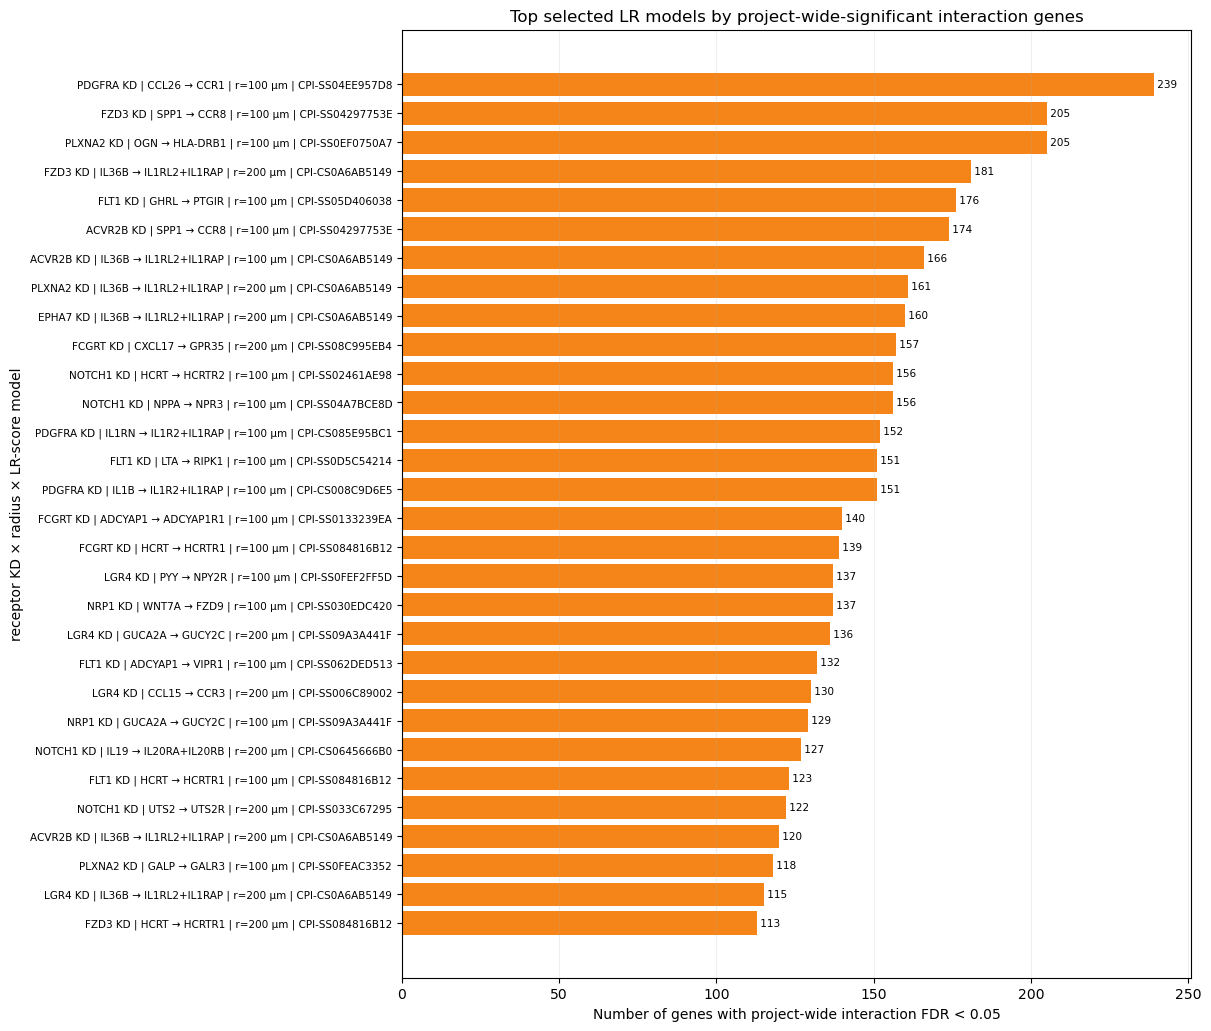

Saved: /scratch/luvul_root/luvul0/luvul/receptor_cytosignal_top_lr_gene_level_ols_results/projectwide_publication_pdf_figures/rank01__PDGFRA__ELAC1__CPI-SS04EE957D8_effect_trajectory.pdf


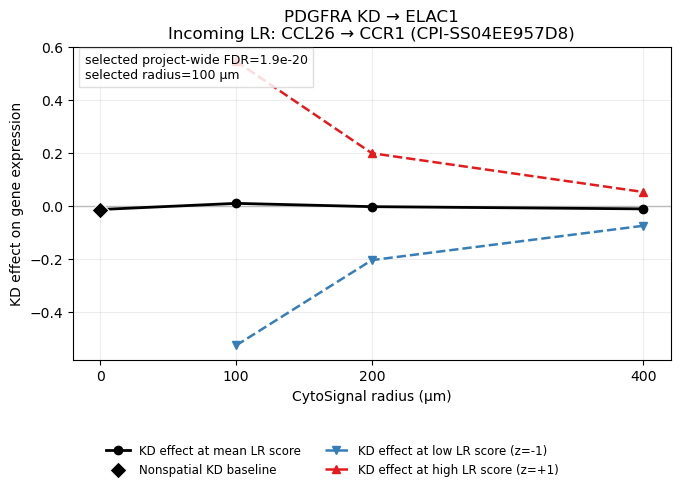

Saved: /scratch/luvul_root/luvul0/luvul/receptor_cytosignal_top_lr_gene_level_ols_results/projectwide_publication_pdf_figures/rank02__FZD3__VWC2L__CPI-SS04297753E_effect_trajectory.pdf


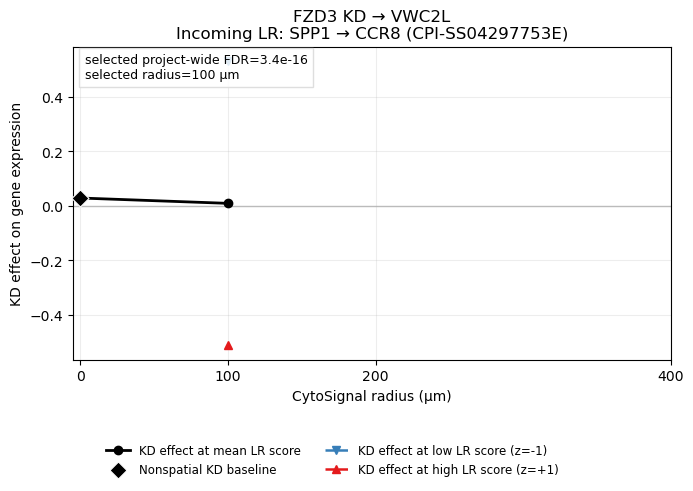

Saved: /scratch/luvul_root/luvul0/luvul/receptor_cytosignal_top_lr_gene_level_ols_results/projectwide_publication_pdf_figures/rank03__PLXNA2__FBXO3__CPI-SS0EF0750A7_effect_trajectory.pdf


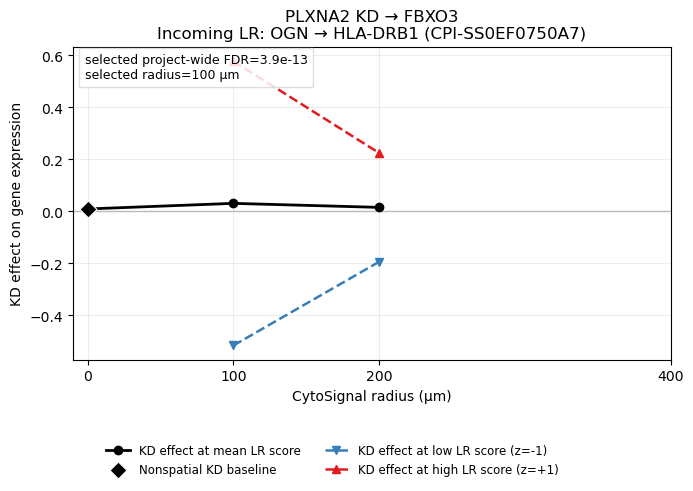

Saved: /scratch/luvul_root/luvul0/luvul/receptor_cytosignal_top_lr_gene_level_ols_results/projectwide_publication_pdf_figures/rank04__FZD3__VWC2L__CPI-CS0A6AB5149_effect_trajectory.pdf


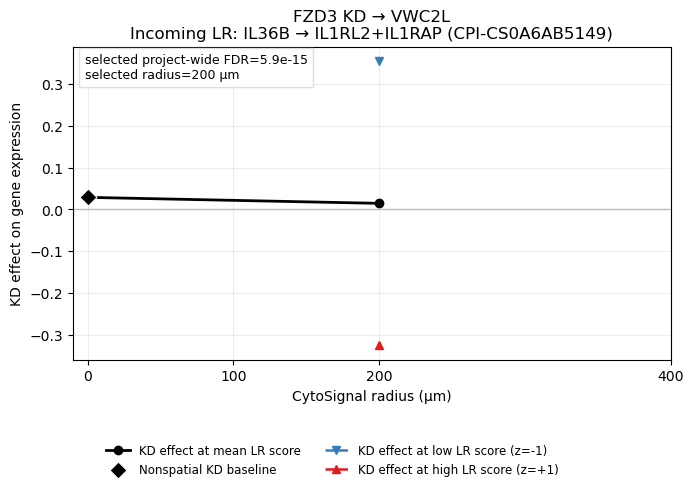

Saved: /scratch/luvul_root/luvul0/luvul/receptor_cytosignal_top_lr_gene_level_ols_results/projectwide_publication_pdf_figures/rank05__FLT1__SUPV3L1__CPI-SS05D406038_effect_trajectory.pdf


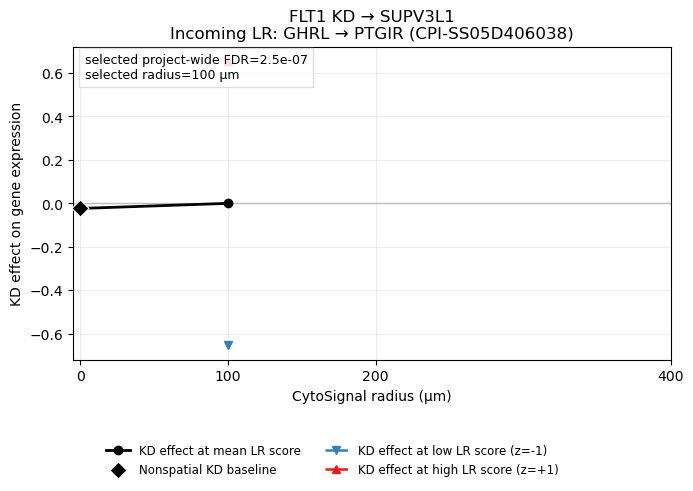

Saved: /scratch/luvul_root/luvul0/luvul/receptor_cytosignal_top_lr_gene_level_ols_results/projectwide_publication_pdf_figures/rank06__ACVR2B__LINC02653__CPI-SS04297753E_effect_trajectory.pdf


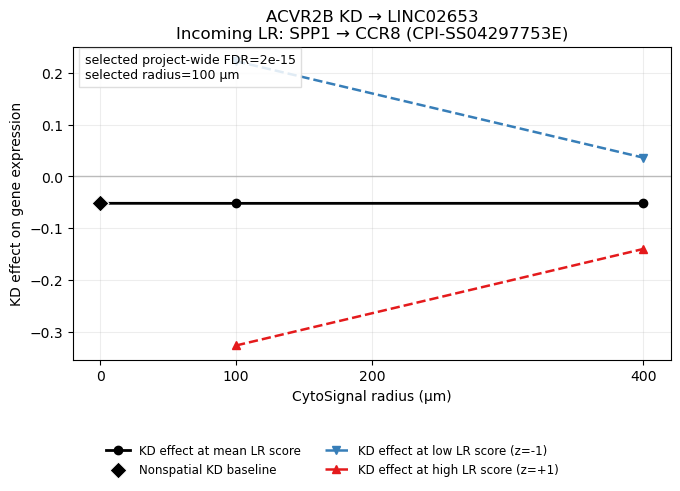

Saved: /scratch/luvul_root/luvul0/luvul/receptor_cytosignal_top_lr_gene_level_ols_results/projectwide_publication_pdf_figures/rank07__ACVR2B__LINC02653__CPI-CS0A6AB5149_effect_trajectory.pdf


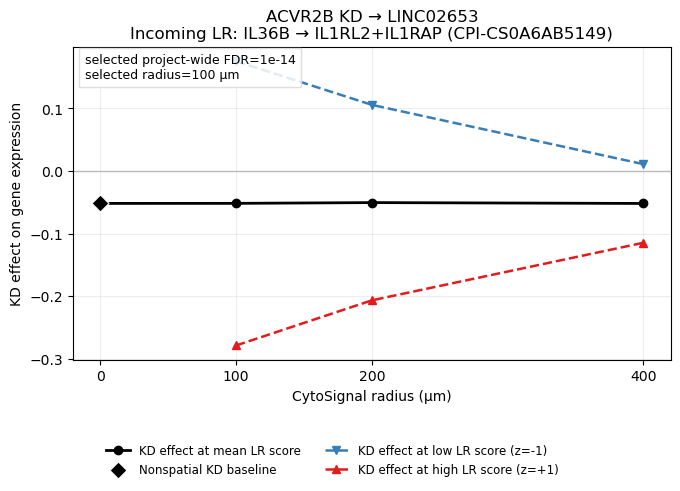

Saved: /scratch/luvul_root/luvul0/luvul/receptor_cytosignal_top_lr_gene_level_ols_results/projectwide_publication_pdf_figures/rank08__PLXNA2__LINC02653__CPI-CS0A6AB5149_effect_trajectory.pdf


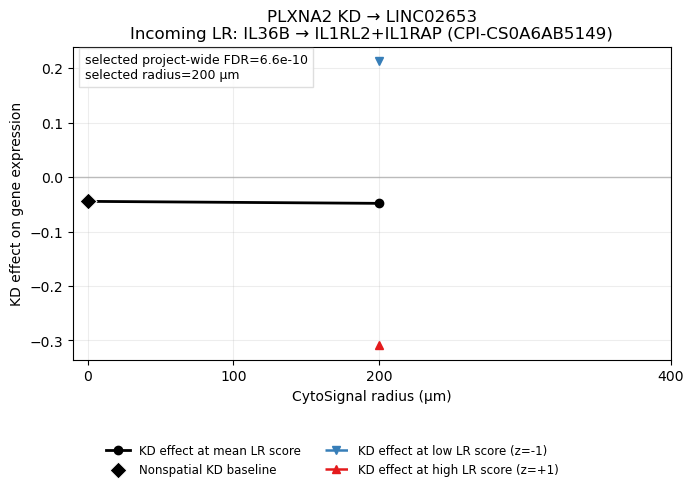

Saved: /scratch/luvul_root/luvul0/luvul/receptor_cytosignal_top_lr_gene_level_ols_results/projectwide_publication_pdf_figures/rank09__EPHA7__SCN11A__CPI-CS0A6AB5149_effect_trajectory.pdf


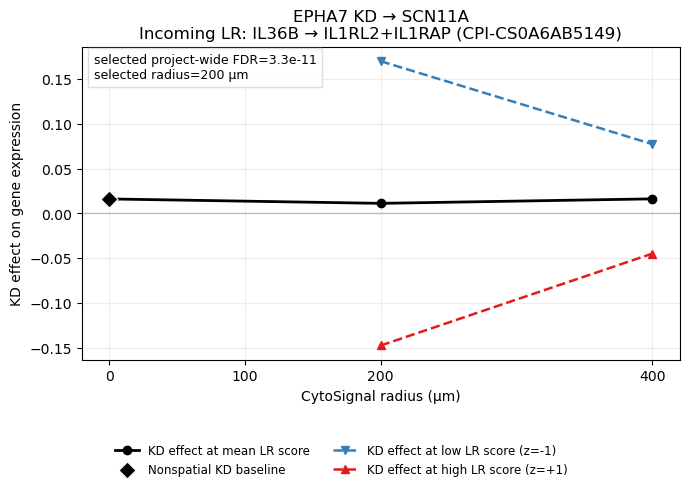

Saved: /scratch/luvul_root/luvul0/luvul/receptor_cytosignal_top_lr_gene_level_ols_results/projectwide_publication_pdf_figures/rank10__FCGRT__ENSG00000258312__CPI-SS08C995EB4_effect_trajectory.pdf


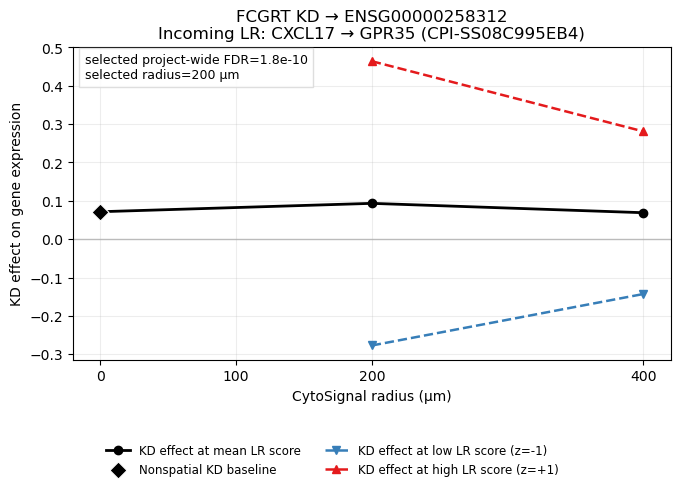

Saved: /scratch/luvul_root/luvul0/luvul/receptor_cytosignal_top_lr_gene_level_ols_results/projectwide_publication_pdf_figures/rank11__NOTCH1__IKZF5__CPI-SS02461AE98_effect_trajectory.pdf


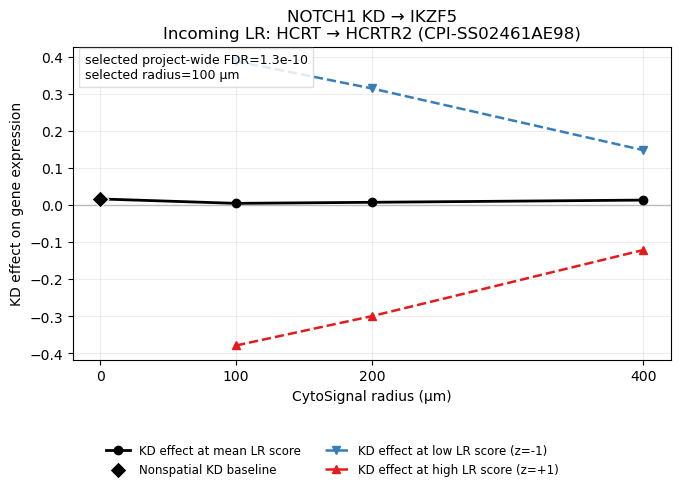

Saved: /scratch/luvul_root/luvul0/luvul/receptor_cytosignal_top_lr_gene_level_ols_results/projectwide_publication_pdf_figures/rank12__NOTCH1__ENSG00000257496__CPI-SS04A7BCE8D_effect_trajectory.pdf


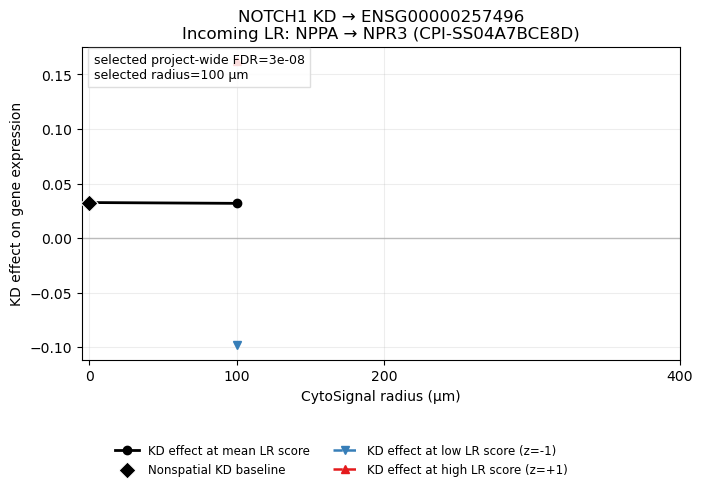

Saved: /scratch/luvul_root/luvul0/luvul/receptor_cytosignal_top_lr_gene_level_ols_results/projectwide_publication_pdf_figures/rank13__PDGFRA__P2RX4__CPI-CS085E95BC1_effect_trajectory.pdf


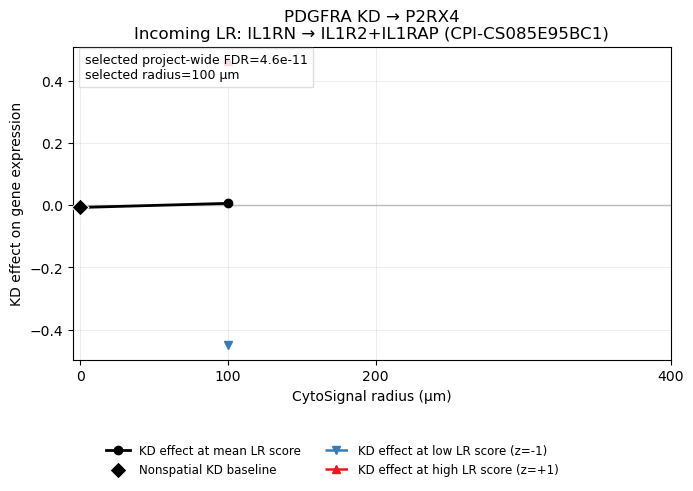

Saved: /scratch/luvul_root/luvul0/luvul/receptor_cytosignal_top_lr_gene_level_ols_results/projectwide_publication_pdf_figures/rank14__FLT1__PPP2R2B__CPI-SS0D5C54214_effect_trajectory.pdf


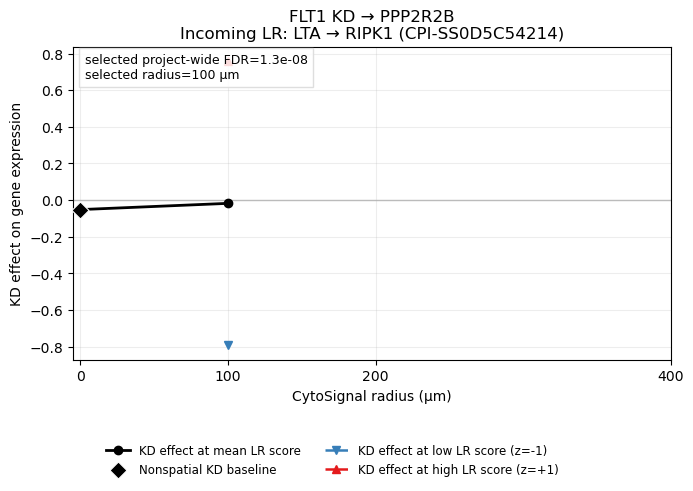

Saved: /scratch/luvul_root/luvul0/luvul/receptor_cytosignal_top_lr_gene_level_ols_results/projectwide_publication_pdf_figures/rank15__PDGFRA__ENSG00000289109__CPI-CS008C9D6E5_effect_trajectory.pdf


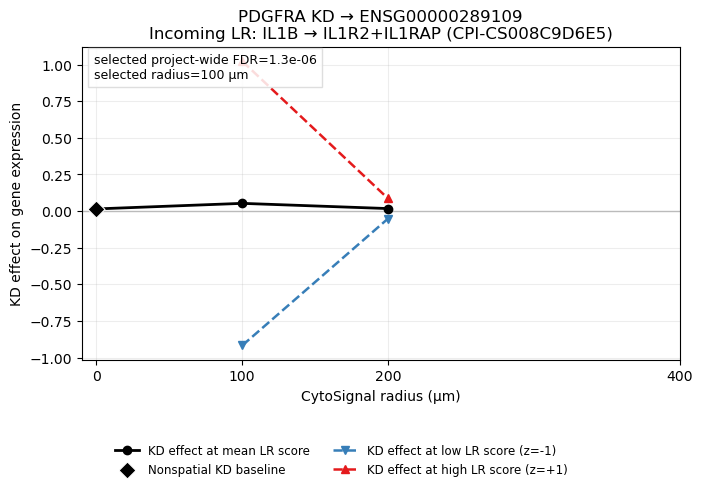

Saved: /scratch/luvul_root/luvul0/luvul/receptor_cytosignal_top_lr_gene_level_ols_results/projectwide_publication_pdf_figures/rank16__FCGRT__COQ7__CPI-SS0133239EA_effect_trajectory.pdf


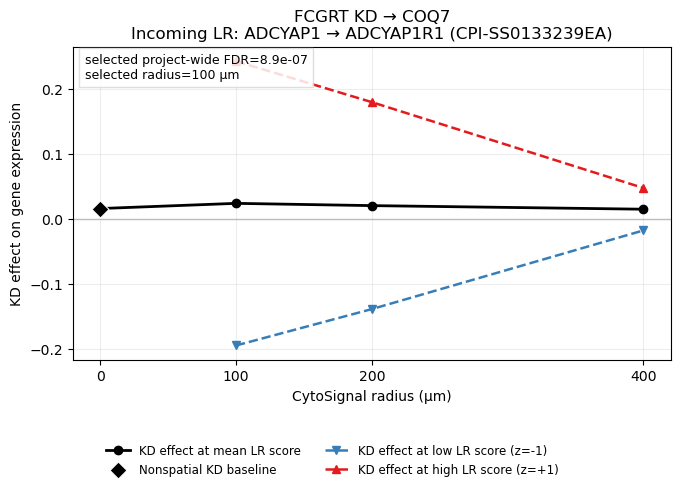

Saved: /scratch/luvul_root/luvul0/luvul/receptor_cytosignal_top_lr_gene_level_ols_results/projectwide_publication_pdf_figures/rank17__FCGRT__CR1L__CPI-SS084816B12_effect_trajectory.pdf


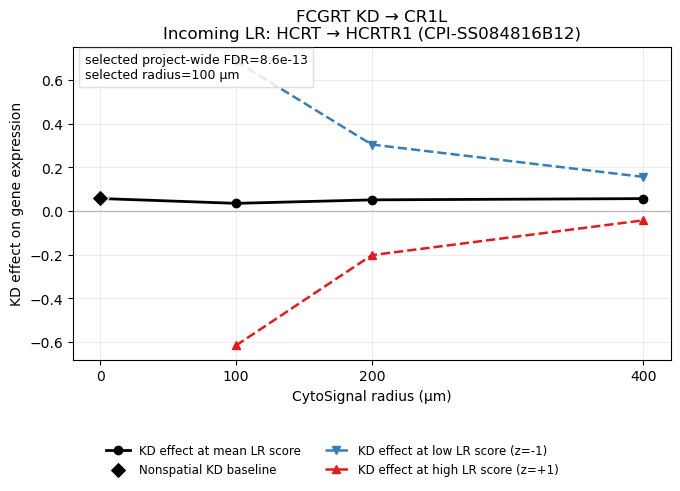

Saved: /scratch/luvul_root/luvul0/luvul/receptor_cytosignal_top_lr_gene_level_ols_results/projectwide_publication_pdf_figures/rank18__LGR4__EPHA3__CPI-SS0FEF2FF5D_effect_trajectory.pdf


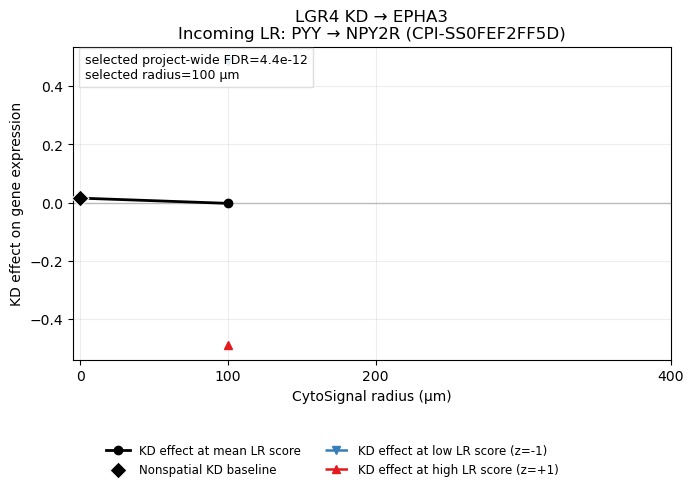

Saved: /scratch/luvul_root/luvul0/luvul/receptor_cytosignal_top_lr_gene_level_ols_results/projectwide_publication_pdf_figures/rank19__NRP1__ANKZF1__CPI-SS030EDC420_effect_trajectory.pdf


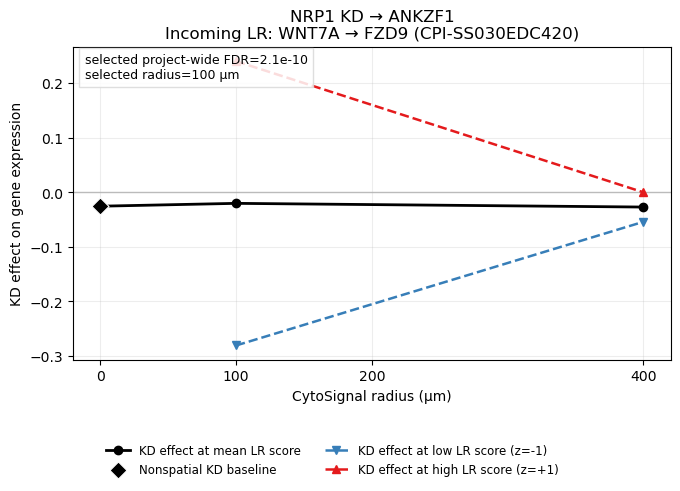

Saved: /scratch/luvul_root/luvul0/luvul/receptor_cytosignal_top_lr_gene_level_ols_results/projectwide_publication_pdf_figures/rank20__LGR4__ADAM32__CPI-SS09A3A441F_effect_trajectory.pdf


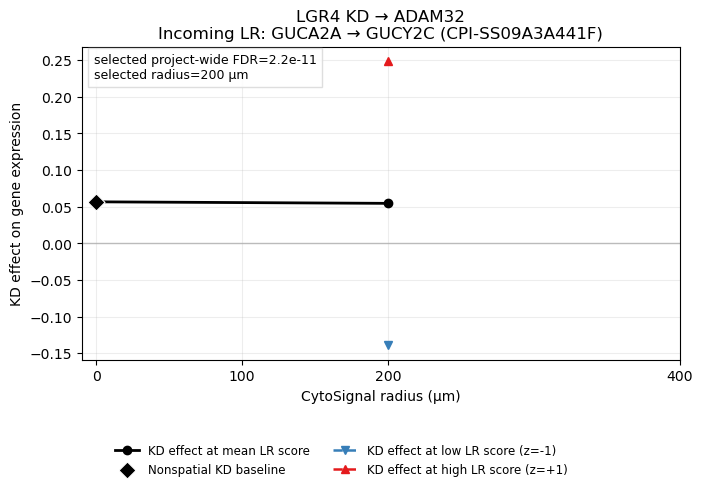

,target,radius_um,lr_var_name,n_genes_tested,n_projectwide_significant_interactions,minimum_p_interaction,minimum_fdr_interaction_projectwide,maximum_abs_beta_interaction,ligand_name,receptor_name,lr_name,lr_type,lr_receptor_contains_kd_target,lr_display_name,model_rank
0,PDGFRA,100,CPI-SS04EE957D8,10924,239,8.200955e-27,1.880696e-20,0.653273,CCL26,CCR1,CCL26_CCR1,diffusion,False,CCL26 → CCR1,1
1,FZD3,100,CPI-SS04297753E,11020,205,4.685235e-22,3.432077e-16,0.836453,SPP1,CCR8,SPP1_CCR8,diffusion,False,SPP1 → CCR8,2
2,PLXNA2,100,CPI-SS0EF0750A7,10945,205,1.220381e-18,3.850931e-13,0.763354,OGN,HLA-DRB1,OGN_HLA-DRB1,diffusion,False,OGN → HLA-DRB1,3
3,FZD3,200,CPI-CS0A6AB5149,11020,181,1.226561e-20,5.850654e-15,0.552428,IL36B,IL1RL2+IL1RAP,IL36B_IL1RL2+IL1RAP,diffusion,False,IL36B → IL1RL2+IL1RAP,4
4,FLT1,100,CPI-SS05D406038,10918,176,1.005660e-11,2.494188e-07,0.653665,GHRL,PTGIR,GHRL_PTGIR,diffusion,False,GHRL → PTGIR,5
5,ACVR2B,100,CPI-SS04297753E,10592,174,3.633180e-21,1.961042e-15,0.286449,SPP1,CCR8,SPP1_CCR8,diffusion,False,SPP1 → CCR8,6
6,ACVR2B,100,CPI-CS0A6AB5149,10592,166,2.272375e-20,1.013225e-14,0.239453,IL36B,IL1RL2+IL1RAP,IL36B_IL1RL2+IL1RAP,diffusion,False,IL36B → IL1RL2+IL1RAP,7
7,PLXNA2,200,CPI-CS0A6AB5149,10945,161,7.324647e-15,6.618270e-10,0.282003,IL36B,IL1RL2+IL1RAP,IL36B_IL1RL2+IL1RAP,diffusion,False,IL36B → IL1RL2+IL1RAP,8
8,EPHA7,200,CPI-CS0A6AB5149,10974,160,2.185441e-16,3.295975e-11,0.261600,IL36B,IL1RL2+IL1RAP,IL36B_IL1RL2+IL1RAP,diffusion,False,IL36B → IL1RL2+IL1RAP,9
9,FCGRT,200,CPI-SS08C995EB4,11077,157,1.605255e-15,1.839393e-10,0.402179,CXCL17,GPR35,CXCL17_GPR35,diffusion,False,CXCL17 → GPR35,10


,target,radius_um,lr_var_name,gene,detection_fraction,beta_kd_nonspatial,se_kd_nonspatial,p_kd_nonspatial,beta_kd,se_kd,p_kd,beta_lr,se_lr,p_lr,beta_interaction,se_interaction,p_interaction,fdr_kd_nonspatial,fdr_kd,fdr_lr,fdr_interaction,ligand_name,receptor_name,lr_name,lr_type,lr_receptor_contains_kd_target,fdr_kd_nonspatial_projectwide,fdr_kd_projectwide,fdr_lr_projectwide,fdr_interaction_projectwide,source_file,model_rank,n_projectwide_significant_interactions,abs_beta_interaction,trajectory_rank,lr_display_name
0,PDGFRA,100,CPI-SS04EE957D8,ELAC1,0.053697,-0.014034,0.015649,0.370027,0.009256,0.015029,0.538084,-0.002790,0.007533,7.111701e-01,0.537417,0.048854,8.200955e-27,0.874172,0.930209,9.927229e-01,8.958723e-23,CCL26,CCR1,CCL26_CCR1,diffusion,False,0.935333,0.962183,9.618923e-01,1.880696e-20,PDGFRA__r100um__CPI-SS04EE957D8_gene_level_ols...,1,239,0.537417,1,CCL26 → CCR1
1,FZD3,100,CPI-SS04297753E,VWC2L,0.059102,0.028981,0.021270,0.173389,0.009394,0.020239,0.642655,0.517935,0.051654,1.979708e-22,-0.521613,0.052521,4.685235e-22,0.830119,0.955204,2.181638e-18,5.163129e-18,SPP1,CCR8,SPP1_CCR8,diffusion,False,0.875510,0.973549,2.497263e-18,3.432077e-16,FZD3__r100um__CPI-SS04297753E_gene_level_ols.c...,2,205,0.521613,2,SPP1 → CCR8
2,PLXNA2,100,CPI-SS0EF0750A7,FBXO3,0.069353,0.009706,0.018939,0.608427,0.031238,0.018428,0.090340,-0.003571,0.009210,6.983207e-01,0.546644,0.060884,1.220381e-18,0.982322,0.838314,8.440067e-01,1.335707e-14,OGN,HLA-DRB1,OGN_HLA-DRB1,diffusion,False,0.969645,0.822264,9.618923e-01,3.850931e-13,PLXNA2__r100um__CPI-SS0EF0750A7_gene_level_ols...,3,205,0.546644,3,OGN → HLA-DRB1
3,FZD3,200,CPI-CS0A6AB5149,VWC2L,0.059102,0.028981,0.021270,0.173389,0.014621,0.020250,0.470483,0.335686,0.034235,1.444789e-21,-0.340384,0.035596,1.226561e-20,0.830119,0.926307,1.592158e-17,1.351670e-16,IL36B,IL1RL2+IL1RAP,IL36B_IL1RL2+IL1RAP,diffusion,False,0.875510,0.953423,1.630922e-17,5.850654e-15,FZD3__r200um__CPI-CS0A6AB5149_gene_level_ols.c...,4,181,0.340384,4,IL36B → IL1RL2+IL1RAP
4,FLT1,100,CPI-SS05D406038,SUPV3L1,0.135204,-0.023771,0.033715,0.480990,-0.000321,0.032939,0.992215,-0.006677,0.014527,6.459301e-01,0.653665,0.094594,1.005660e-11,0.952703,0.998714,9.200267e-01,1.097979e-07,GHRL,PTGIR,GHRL_PTGIR,diffusion,False,0.953667,0.999543,9.618923e-01,2.494188e-07,FLT1__r100um__CPI-SS05D406038_gene_level_ols.c...,5,176,0.653665,5,GHRL → PTGIR
5,ACVR2B,100,CPI-SS04297753E,LINC02653,0.060893,-0.051900,0.020352,0.010836,-0.051994,0.019916,0.009098,0.272079,0.027202,4.567457e-23,-0.274094,0.028732,3.633180e-21,0.118575,0.105539,4.837851e-19,3.848264e-17,SPP1,CCR8,SPP1_CCR8,diffusion,False,0.587422,0.571700,6.300096e-19,1.961042e-15,ACVR2B__r100um__CPI-SS04297753E_gene_level_ols...,6,174,0.274094,6,SPP1 → CCR8
6,ACVR2B,100,CPI-CS0A6AB5149,LINC02653,0.060893,-0.051900,0.020352,0.010836,-0.051788,0.019912,0.009362,0.224728,0.022369,2.978866e-23,-0.227043,0.024309,2.272375e-20,0.118575,0.106857,3.155215e-19,2.406900e-16,IL36B,IL1RL2+IL1RAP,IL36B_IL1RL2+IL1RAP,diffusion,False,0.587422,0.575916,4.210825e-19,1.013225e-14,ACVR2B__r100um__CPI-CS0A6AB5149_gene_level_ols...,7,166,0.227043,7,IL36B → IL1RL2+IL1RAP
7,PLXNA2,200,CPI-CS0A6AB5149,LINC02653,0.070291,-0.044640,0.028961,0.123516,-0.048291,0.027976,0.084608,0.257084,0.028999,3.155058e-18,-0.260968,0.033065,7.324647e-15,0.867939,0.825574,3.453211e-14,6.851567e-11,IL36B,IL1RL2+IL1RAP,IL36B_IL1RL2+IL1RAP,diffusion,False,0.845181,0.817027,2.085495e-14,6.618270e-10,PLXNA2__r200um__CPI-CS0A6AB5149_gene_level_ols...,8,161,0.260968,8,IL36B → IL1RL2+IL1RAP
8,EPHA7,200,CPI-CS0A6AB5149,SCN11A,0.051669,0.016120,0.015287,0.291863,0.011185,0.014842,0.451219,0.154334,0.017217,1.108816e-18,-0.158721,0.019066,2.185441e-16,0.989602,0.990009,1.216814e-14,2.398303e-12,IL36B,IL1RL2+IL1RAP,IL36B_IL1RL2+IL1RAP,diffusion,False,0.917623,0.950701,7.968728e-15,3.295975e-11,EPHA7__r200um__CPI-CS0A6AB5149_gene_level_ols....,9,160,0.158721,9,IL36B → IL1RL2+IL1RAP
9,FCGRT,200,CPI-SS08C995EB4,ENSG00000258312,0.0623

,file,path
0,rank01__PDGFRA__ELAC1__CPI-SS04EE957D8_effect_...,/scratch/luvul_root/luvul0/luvul/receptor_cyto...
1,rank02__FZD3__VWC2L__CPI-SS04297753E_effect_tr...,/scratch/luvul_root/luvul0/luvul/receptor_cyto...
2,rank03__PLXNA2__FBXO3__CPI-SS0EF0750A7_effect_...,/scratch/luvul_root/luvul0/luvul/receptor_cyto...
3,rank04__FZD3__VWC2L__CPI-CS0A6AB5149_effect_tr...,/scratch/luvul_root/luvul0/luvul/receptor_cyto...
4,rank05__FLT1__SUPV3L1__CPI-SS05D406038_effect_...,/scratch/luvul_root/luvul0/luvul/receptor_cyto...
5,rank06__ACVR2B__LINC02653__CPI-SS04297753E_eff...,/scratch/luvul_root/luvul0/luvul/receptor_cyto...
6,rank07__ACVR2B__LINC02653__CPI-CS0A6AB5149_eff...,/scratch/luvul_root/luvul0/luvul/receptor_cyto...
7,rank08__PLXNA2__LINC02653__CPI-CS0A6AB5149_eff...,/scratch/luvul_root/luvul0/luvul/receptor_cyto...
8,rank09__EPHA7__SCN11A__CPI-CS0A6AB5149_effect_...,/scratch/luvul_root/luvul0/luvul/receptor_cyto...
9,rank10__FCGRT__ENSG00000258312__CPI-SS08C995EB...,/scratch/luvul_root/luvul0/luvul/receptor_cyto...


Publication PDF output directory: /scratch/luvul_root/luvul0/luvul/receptor_cytosignal_top_lr_gene_level_ols_results/projectwide_publication_pdf_figures


In [7]:
import matplotlib as mpl

mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42

PUBLICATION_RECEPTOR_TARGETS = {
    'ACVR2B', 'EPHA7', 'FCGRT', 'FLT1', 'FZD3',
    'LGR4', 'NOTCH1', 'NRP1', 'PDGFRA', 'PLXNA2',
}
PUBLICATION_TOP_N_MODELS = 30
PUBLICATION_TOP_N_TRAJECTORIES = 20
PUBLICATION_FDR_ALPHA = 0.05
PUBLICATION_FIGURE_DIR = OUTPUT_DIR / 'projectwide_publication_pdf_figures'
PUBLICATION_FIGURE_DIR.mkdir(parents=True, exist_ok=True)

publication_pointer = OUTPUT_DIR / 'projectwide_fdr_posthoc' / 'LATEST_PROJECTWIDE_FDR.json'
if not publication_pointer.is_file():
    raise RuntimeError(
        'Completed project-wide FDR output was not found. Run the preceding '
        f'project-wide FDR section first: {publication_pointer}'
    )
publication_metadata = json.loads(publication_pointer.read_text())
if publication_metadata.get('status') != 'completed':
    raise RuntimeError(f'Project-wide FDR is incomplete: {publication_metadata}')
publication_run_dir = Path(publication_metadata['run_dir'])
publication_summary_path = publication_run_dir / 'projectwide_interaction_summary.csv'
publication_events_path = publication_run_dir / 'projectwide_significant_interaction_events.csv.gz'
for required_path in [publication_summary_path, publication_events_path]:
    if not required_path.is_file():
        raise FileNotFoundError(required_path)

publication_model_summary = pd.read_csv(publication_summary_path)
publication_events = pd.read_csv(publication_events_path)
publication_annotation = pd.read_csv(
    OUTPUT_DIR / 'input_candidate_lr_scores_with_direct_match_flag.csv'
)
model_key = ['target', 'radius_um', 'lr_var_name']
event_key = model_key + ['gene']
for frame in [publication_model_summary, publication_events, publication_annotation]:
    frame['target'] = frame['target'].astype(str)
    frame['radius_um'] = frame['radius_um'].astype(int)
    frame['lr_var_name'] = frame['lr_var_name'].astype(str)
if publication_annotation.duplicated(model_key).any():
    publication_annotation = publication_annotation.sort_values(model_key).drop_duplicates(model_key, keep='first')
annotation_columns = model_key + [
    column for column in ['ligand_name', 'receptor_name', 'lr_name', 'lr_type', 'lr_receptor_contains_kd_target']
    if column in publication_annotation.columns
]
publication_model_summary = publication_model_summary.merge(
    publication_annotation[annotation_columns],
    on=model_key,
    how='left',
    validate='one_to_one',
)

def _publication_lr_display(frame):
    ligand = frame.get('ligand_name', pd.Series('', index=frame.index)).fillna('').astype(str).str.strip()
    receptor = frame.get('receptor_name', pd.Series('', index=frame.index)).fillna('').astype(str).str.strip()
    lr_name = frame.get('lr_name', pd.Series('', index=frame.index)).fillna('').astype(str).str.strip()
    return np.where(
        ligand.ne('') & receptor.ne(''),
        ligand + ' → ' + receptor,
        np.where(lr_name.ne(''), lr_name, frame['lr_var_name'].astype(str)),
    )

publication_model_summary['lr_display_name'] = _publication_lr_display(publication_model_summary)
publication_model_summary = publication_model_summary.loc[
    publication_model_summary['target'].isin(PUBLICATION_RECEPTOR_TARGETS)
    & publication_model_summary['n_projectwide_significant_interactions'].gt(0)
].copy()
publication_model_summary = publication_model_summary.sort_values(
    ['n_projectwide_significant_interactions', 'minimum_fdr_interaction_projectwide'],
    ascending=[False, True],
    ignore_index=True,
)
top_publication_models = publication_model_summary.head(PUBLICATION_TOP_N_MODELS).copy()
top_publication_models['model_rank'] = np.arange(1, len(top_publication_models) + 1)
top_publication_models.to_csv(
    PUBLICATION_FIGURE_DIR / 'top_projectwide_significant_lr_models.csv',
    index=False,
)

if top_publication_models.empty:
    raise RuntimeError('No receptor LR model has a project-wide-significant interaction gene.')

# Figure 1: overview of top LR models by significant interaction-gene count.
overview = top_publication_models.iloc[::-1].copy()
overview['plot_label'] = (
    overview['target'].astype(str) + ' KD | '
    + overview['lr_display_name'].astype(str) + ' | r='
    + overview['radius_um'].astype(str) + ' µm | '
    + overview['lr_var_name'].astype(str)
)
fig, ax = plt.subplots(
    figsize=(12, max(6.5, 0.34 * len(overview))),
    constrained_layout=True,
)
bars = ax.barh(
    np.arange(len(overview)),
    overview['n_projectwide_significant_interactions'],
    color='#F58518',
)
ax.set_yticks(np.arange(len(overview)))
ax.set_yticklabels(overview['plot_label'], fontsize=7.5)
ax.set_xlabel('Number of genes with project-wide interaction FDR < 0.05')
ax.set_ylabel('receptor KD × radius × LR-score model')
ax.set_title('Top selected LR models by project-wide-significant interaction genes')
ax.grid(axis='x', alpha=0.2)
for bar, count in zip(bars, overview['n_projectwide_significant_interactions']):
    ax.text(
        bar.get_width(), bar.get_y() + bar.get_height() / 2,
        f' {int(count)}', ha='left', va='center', fontsize=7.5,
    )
overview_pdf_path = PUBLICATION_FIGURE_DIR / 'top_selected_lr_models_projectwide_significant_gene_counts.pdf'
fig.savefig(overview_pdf_path, format='pdf', bbox_inches='tight')
print('Saved:', overview_pdf_path)
plt.show()

# Select one strongest project-wide-significant gene event from the highest-ranked models.
publication_events['gene'] = publication_events['gene'].astype(str)
publication_events = publication_events.loc[
    publication_events['target'].isin(PUBLICATION_RECEPTOR_TARGETS)
    & publication_events['fdr_interaction_projectwide'].lt(PUBLICATION_FDR_ALPHA)
].copy()
candidate_model_ranks = top_publication_models[model_key + ['model_rank', 'n_projectwide_significant_interactions']]
publication_event_candidates = publication_events.merge(
    candidate_model_ranks,
    on=model_key,
    how='inner',
    validate='many_to_one',
)
publication_event_candidates['abs_beta_interaction'] = pd.to_numeric(
    publication_event_candidates['beta_interaction'], errors='coerce'
).abs()
publication_event_candidates = publication_event_candidates.sort_values(
    ['model_rank', 'fdr_interaction_projectwide', 'abs_beta_interaction'],
    ascending=[True, True, False],
)
top_publication_events = (
    publication_event_candidates
    .drop_duplicates(model_key, keep='first')
    .drop_duplicates(['target', 'lr_var_name', 'gene'], keep='first')
    .head(PUBLICATION_TOP_N_TRAJECTORIES)
    .reset_index(drop=True)
)
top_publication_events['trajectory_rank'] = np.arange(1, len(top_publication_events) + 1)
top_publication_events['lr_display_name'] = _publication_lr_display(top_publication_events)
top_publication_events.to_csv(
    PUBLICATION_FIGURE_DIR / 'top_projectwide_significant_trajectory_candidates.csv',
    index=False,
)

def _publication_safe_name(value):
    return re.sub(r'[^A-Za-z0-9_.-]+', '_', str(value)).strip('_')

def _publication_read_gene_event(target, radius_um, lr_var_name, gene):
    path = OUTPUT_DIR / (
        f'{_publication_safe_name(target)}__r{int(radius_um)}um__'
        f'{_publication_safe_name(lr_var_name)}_gene_level_ols.csv.gz'
    )
    if not path.is_file():
        return None
    try:
        frame = pd.read_csv(path)
    except pd.errors.EmptyDataError:
        return None
    hit = frame.loc[frame['gene'].astype(str).eq(str(gene))]
    if hit.empty:
        return None
    row = hit.iloc[0].to_dict()
    row['result_file'] = str(path)
    return row

publication_trajectory_rows = []
for _, candidate in top_publication_events.iterrows():
    target = str(candidate['target'])
    lr_var_name = str(candidate['lr_var_name'])
    gene = str(candidate['gene'])
    spatial_rows = []
    for radius_um in sorted(int(radius) for radius in RADIUS_LAYERS):
        row = _publication_read_gene_event(target, radius_um, lr_var_name, gene)
        if row is None:
            continue
        row['trajectory_rank'] = int(candidate['trajectory_rank'])
        row['selected_model_radius_um'] = int(candidate['radius_um'])
        row['selected_fdr_interaction_projectwide'] = float(candidate['fdr_interaction_projectwide'])
        row['selected_n_projectwide_significant_interactions'] = int(candidate['n_projectwide_significant_interactions'])
        row['trajectory_target'] = target
        row['trajectory_lr_var_name'] = lr_var_name
        row['trajectory_lr_display_name'] = str(candidate['lr_display_name'])
        row['trajectory_gene'] = gene
        row['radius_um'] = int(radius_um)
        row['conditional_kd_effect_low_score'] = row['beta_kd'] - row['beta_interaction']
        row['conditional_kd_effect_high_score'] = row['beta_kd'] + row['beta_interaction']
        row['trajectory_point_type'] = 'spatial_lr_model'
        spatial_rows.append(row)
        publication_trajectory_rows.append(row)
    if spatial_rows and pd.notna(spatial_rows[0].get('beta_kd_nonspatial')):
        baseline = dict(spatial_rows[0])
        baseline['radius_um'] = 0
        baseline['beta_kd'] = baseline.get('beta_kd_nonspatial', np.nan)
        baseline['conditional_kd_effect_low_score'] = np.nan
        baseline['conditional_kd_effect_high_score'] = np.nan
        baseline['trajectory_point_type'] = 'nonspatial_kd_baseline'
        publication_trajectory_rows.append(baseline)

publication_trajectory = pd.DataFrame(publication_trajectory_rows)
if not publication_trajectory.empty:
    publication_trajectory = publication_trajectory.sort_values(
        ['trajectory_rank', 'radius_um'], ignore_index=True
    )
publication_trajectory.to_csv(
    PUBLICATION_FIGURE_DIR / 'top_projectwide_significant_effect_trajectories.csv',
    index=False,
)

if publication_trajectory.empty:
    print('No project-wide-significant trajectory data were available.')
else:
    for trajectory_rank, sub in publication_trajectory.groupby('trajectory_rank', sort=True):
        sub = sub.sort_values('radius_um')
        first = sub.iloc[0]
        target = str(first['trajectory_target'])
        gene = str(first['trajectory_gene'])
        lr_var_name = str(first['trajectory_lr_var_name'])
        lr_display_name = str(first['trajectory_lr_display_name'])
        spatial = sub.loc[sub['radius_um'].gt(0)].copy()
        fig, ax = plt.subplots(figsize=(7.2, 5.3), constrained_layout=False)
        ax.axhline(0, color='0.75', linewidth=1, zorder=0)
        kd_line = sub[['radius_um', 'beta_kd']].dropna().sort_values('radius_um')
        ax.plot(
            kd_line['radius_um'], kd_line['beta_kd'],
            color='black', marker='o', linewidth=2.0,
            label='KD effect at mean LR score',
        )
        baseline = sub.loc[sub['radius_um'].eq(0)]
        if not baseline.empty:
            ax.scatter(
                baseline['radius_um'], baseline['beta_kd'],
                marker='D', s=75, color='black', edgecolors='white',
                linewidths=0.8, zorder=4,
                label='Nonspatial KD baseline',
            )
        if not spatial.empty:
            ax.plot(
                spatial['radius_um'], spatial['conditional_kd_effect_low_score'],
                color='#377EB8', marker='v', linestyle='--', linewidth=1.8,
                label='KD effect at low LR score (z=-1)',
            )
            ax.plot(
                spatial['radius_um'], spatial['conditional_kd_effect_high_score'],
                color='#E41A1C', marker='^', linestyle='--', linewidth=1.8,
                label='KD effect at high LR score (z=+1)',
            )
        ax.set_xticks([0, 100, 200, 400])
        ax.set_xlabel('CytoSignal radius (µm)')
        ax.set_ylabel('KD effect on gene expression')
        ax.set_title(
            f'{target} KD → {gene}\nIncoming LR: {lr_display_name} ({lr_var_name})'
        )
        ax.grid(alpha=0.22)
        ax.text(
            0.02, 0.98,
            f"selected project-wide FDR={first['selected_fdr_interaction_projectwide']:.2g}\n"
            f"selected radius={int(first['selected_model_radius_um'])} µm",
            transform=ax.transAxes, ha='left', va='top', fontsize=9,
            bbox=dict(facecolor='white', edgecolor='0.85', alpha=0.85),
        )
        handles, labels = ax.get_legend_handles_labels()
        unique = dict(zip(labels, handles))
        fig.legend(
            unique.values(), unique.keys(),
            loc='lower center', bbox_to_anchor=(0.5, 0.01),
            ncol=2, frameon=False, fontsize=8.5,
        )
        fig.subplots_adjust(left=0.14, right=0.97, top=0.84, bottom=0.25)
        trajectory_pdf_path = PUBLICATION_FIGURE_DIR / (
            f'rank{int(trajectory_rank):02d}__{_publication_safe_name(target)}__'
            f'{_publication_safe_name(gene)}__{_publication_safe_name(lr_var_name)}_effect_trajectory.pdf'
        )
        fig.savefig(trajectory_pdf_path, format='pdf', bbox_inches='tight')
        print('Saved:', trajectory_pdf_path)
        plt.show()

publication_figure_manifest = pd.DataFrame({
    'file': [path.name for path in sorted(PUBLICATION_FIGURE_DIR.glob('*.pdf'))],
    'path': [str(path) for path in sorted(PUBLICATION_FIGURE_DIR.glob('*.pdf'))],
})
publication_figure_manifest.to_csv(
    PUBLICATION_FIGURE_DIR / 'publication_pdf_figure_manifest.csv',
    index=False,
)
display(top_publication_models.head(30))
display(top_publication_events)
display(publication_figure_manifest)
print('Publication PDF output directory:', PUBLICATION_FIGURE_DIR)
